In [4]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,angle_to_open_corner,turn_direction_left_right
from pipeline.oa_calculations import *
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [5]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})

In [4]:
def get_median_trajectory(df, x_key: str, y_key: str, 
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate median trajectory by interpolating y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both median and all interpolated trajectories
    
    Returns:
    - Median trajectory (and optionally all trajectories)
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
   
    
   ## Set distance bins based on turn direction and start position
   #if turn_direction == 'left' and start_position == 'bottom':
   #    distance_bins = np.arange(9, 50, 1)    # Left turns from bottom left
   #elif turn_direction == 'right' and start_position == 'bottom':
   #    distance_bins = np.arange(45, 0, -1)   # Right turns from bottom right
   #elif turn_direction == 'left' and start_position == 'top':
   #    distance_bins = np.arange(45, 0, -1) 
   #elif turn_direction == 'right' and start_position == 'top':
   #    distance_bins = np.arange(9, 50, 1) 

        # Set distance bins based on turn direction and start position
 
    if turn_direction == 'left':
        distance_bins = np.arange(55, 13, -1)    # Left turns from bottom left
    elif turn_direction == 'right':
        distance_bins = np.arange(7, 50, 1)   # Right turns from bottom right
  
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan  # Initialize with NaNs
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        # Remove duplicate x-values (keep first occurrence)
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        # Only interpolate if we have at least 2 points
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    # Calculate median trajectory
    median_trajectory = np.nanmedian(trajectory_matrix, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_median = pd.Series(median_trajectory)
    valid_median.fillna(method='bfill', inplace=True)
    valid_median.fillna(method='ffill', inplace=True)
    median_trajectory = valid_median.to_numpy()
    
    if return_matrix:
        return median_trajectory, trajectory_matrix
    else:
        return median_trajectory,distance_bins

In [7]:
def ts_calculate_relative_distance(df):
    """calculates relative distance of nose to point on obstacle using x-coordinate only"""
    for direction, direction_frame in df.groupby(['odd']):
        for ind, row in direction_frame.iterrows():  
            if direction == 'right':
                try:
                    nose_x = row['ts_nose_x_cm']
                    distances = []
                    for i, x_pos in enumerate(nose_x):
                        obstacle_x = np.mean([row['gt_obstacleTR_x_cm'], row['gt_obstacleBR_x_cm']])
                        
                        # Calculate distance as simple x-coordinate difference
                        distance = x_pos - obstacle_x
                        distances.append(distance)
                        
                except (IndexError, TypeError):
                    distances = [np.nan]
                
                df.at[ind, 'ts_distance_from_edge'] = np.array(distances).astype(object)
                df.at[ind, 'ts_len_distance_from_edge'] = np.array(distances).astype(object).size
                
            if direction == 'left':
                try:
                    nose_x = row['ts_nose_x_cm']
                    distances = []
                    for i, x_pos in enumerate(nose_x):
                        obstacle_x = np.mean([row['gt_obstacleTL_x_cm'], row['gt_obstacleBL_x_cm']])
                        
                        # Calculate distance as simple x-coordinate difference
                        distance = x_pos - obstacle_x
                        distances.append(distance)
                        
                except (IndexError, TypeError):
                    distances = [np.nan]
                
                df.at[ind, 'ts_distance_from_edge'] = np.array(distances).astype(object)
                df.at[ind, 'ts_len_distance_from_edge'] = np.array(distances).astype(object).size

In [12]:
import pandas as pd
import os

def split_and_save_dataframe(df, split_ratio, output_dir, filename_prefix):
    """
    Split a DataFrame and save parts as H5 files.
    
    Parameters:
    - df: pandas DataFrame to split
    - split_ratio: fraction of data to go to first file (0.0 to 1.0)
    - output_dir: directory to save files
    - filename_prefix: prefix for output filenames
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Split the DataFrame
    split_index = int(len(df) * split_ratio)
    df1 = df.iloc[:split_index]
    df2 = df.iloc[split_index:]
    
    # Create filenames
    file1 = os.path.join(output_dir, f"{filename_prefix}_part1.h5")
    file2 = os.path.join(output_dir, f"{filename_prefix}_part2.h5")
    
    # Save to HDF5 format
    df1.to_hdf(file1, key='data', mode='w')
    df2.to_hdf(file2, key='data', mode='w')
    
    print(f"Data saved to:\n- {file1}\n- {file2}")

In [4]:
np.set_printoptions(suppress=True)

In [42]:
def calculate_relative_distance_goal_ts2(df):
    '''Calculates change in distance from nose to goal port using:
    - Absolute x-distance (nose_x - port_x)
    - Only first occurrence of each x-position'''
    
    for direction, direction_frame in df.groupby(['odd']):
        for ind, row in direction_frame.iterrows():  
            try:
                nose_x = row['ts_nose_x_cm'].astype(float)
                processed_x = set()  # Track seen x positions
                
                if direction == 'right':
                    port_x_tar = np.nanmean([row['leftportB_x_cm'], row['leftportT_x_cm']])
                    port_x_start = np.nanmean([row['rightportB_x_cm'], row['rightportT_x_cm']])
                else:
                    port_x_tar = np.nanmean([row['rightportB_x_cm'], row['rightportT_x_cm']])
                    port_x_start = np.nanmean([row['leftportB_x_cm'], row['leftportT_x_cm']])
                
                distances_tar = []
                distances_start = []
                
                for i, x in enumerate(nose_x):
                    if x not in processed_x:  # Only process first occurrence
                        processed_x.add(x)
                        # Calculate absolute x-distances
                        distance_tar = abs(x - port_x_tar)
                        distance_start = abs(x - port_x_start)
                        distances_tar.append(distance_tar)
                        distances_start.append(distance_start)
                
                df.at[ind, 'ts_distance_from_target_port'] = np.array(distances_tar).astype(object)
                df.at[ind, 'ts_distance_from_start_port'] = np.array(distances_start).astype(object)
                
            except (KeyError, TypeError, ValueError) as e:
                # Store NaN arrays if any error occurs
                df.at[ind, 'ts_distance_from_target_port'] = np.array([np.nan]).astype(object)
                df.at[ind, 'ts_distance_from_start_port'] = np.array([np.nan]).astype(object)
    
    return df

In [48]:
light_dark.obstacle_ind[0]

159.0

In [49]:
light_dark.ts_distance_from_target_port[0].shape

(232,)

In [ ]:
def get_median_trajectory(df, x_key: str, y_key: str, 
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate median trajectory by interpolating y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both median and all interpolated trajectories
    
    Returns:
    - Median trajectory (and optionally all trajectories)
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
    start_position = df[start_position_key].iloc[0].lower()
    
    # Set distance bins based on turn direction and start position
    if turn_direction == 'left' and start_position == 'bottom':
        distance_bins = np.arange(9, 50, 1)    # Left turns from bottom left
    elif turn_direction == 'right' and start_position == 'bottom':
        distance_bins = np.arange(45, 0, -1)   # Right turns from bottom right
    elif turn_direction == 'left' and start_position == 'top':
        distance_bins = np.arange(45, 0, -1) 
    elif turn_direction == 'right' and start_position == 'top':
        distance_bins = np.arange(9, 50, 1) 
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan  # Initialize with NaNs
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        # Remove duplicate x-values (keep first occurrence)
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        # Only interpolate if we have at least 2 points
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    # Calculate median trajectory
    median_trajectory = np.nanmedian(trajectory_matrix, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_median = pd.Series(median_trajectory)
    valid_median.fillna(method='bfill', inplace=True)
    valid_median.fillna(method='ffill', inplace=True)
    median_trajectory = valid_median.to_numpy()
    
    if return_matrix:
        return median_trajectory, trajectory_matrix
    else:
        return median_trajectory

In [11]:
light_dark_1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5")
light_dark_2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5")
light_dark = pd.concat([light_dark_1,light_dark_2])

In [65]:
def calculate_relative_distance_goal_ts2(df):
    '''Calculates change in distance from nose to goal port using:
    - Absolute x-distance (nose_x - port_x)
    - Only first occurrence of each x-position'''
    
    for direction, direction_frame in df.groupby(['odd']):
        for ind, row in direction_frame.iterrows():  
            try:
                nose_x = row['ts_nose_x_cm'].astype(float)
                processed_x = set()  # Track seen x positions
                
                if direction == 'right':
                    port_x_tar = np.nanmean([row['leftportB_x_cm'], row['leftportT_x_cm']])
                    port_x_start = np.nanmean([row['rightportB_x_cm'], row['rightportT_x_cm']])
                else:
                    port_x_tar = np.nanmean([row['rightportB_x_cm'], row['rightportT_x_cm']])
                    port_x_start = np.nanmean([row['leftportB_x_cm'], row['leftportT_x_cm']])
                
                distances_tar = []
                distances_start = []
                
                for i, x in enumerate(nose_x):
                    if x not in processed_x:  # Only process first occurrence
                        processed_x.add(x)
                        # Calculate absolute x-distances
                        distance_tar = abs(x - port_x_tar)
                        distance_start = abs(x - port_x_start)
                        distances_tar.append(distance_tar)
                        distances_start.append(distance_start)
                
                df.at[ind, 'ts_distance_from_target_port'] = np.array(distances_tar).astype(object)
                df.at[ind, 'ts_distance_from_start_port'] = np.array(distances_start).astype(object)
                
            except (KeyError, TypeError, ValueError) as e:
                # Store NaN arrays if any error occurs
                df.at[ind, 'ts_distance_from_target_port'] = np.array([np.nan]).astype(object)
                df.at[ind, 'ts_distance_from_start_port'] = np.array([np.nan]).astype(object)

In [13]:
ts_calculate_relative_distance(light_dark)

In [43]:
calculate_relative_distance_goal_ts2(light_dark)

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,angles_at_head_turns_ends,avg_speed,avg_ts_speed,head_angle_whole_trial,head_angle_velocity_whole_trial,turn_direction_left_right,intial_distance,goal_distance_from_target_port,goal_angle_to_target_port,goal_lateral_error_to_target_port
0,0,48054.835737,48059.792371,"[48054.850086, 48054.866291, 48054.883008, 480...","[[718, 719, 720, 721, 722, 723, 724, 725, 726,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.5863647460938, 647.6791381835938, 647.953...","[256.8539123535156, 256.5686340332031, 256.810...","[655.6896362304688, 655.893798828125, 656.1171...",...,"[0.4748630033916924, 13.206937651525928, 29.11...",17.107891,17.150953,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-2.5067424782757053, -3.975730695107509, -3.9...",left,23.0,"[22.0959312118867, 21.663251903654018, 21.2305...","[7.429573008006076, 3.8913678278574193, 6.6502...","[8.090737985945012, 8.097815708845173, 8.10489..."
1,1,48059.792371,48066.055564,"[48059.801369, 48059.818099, 48059.834739, 480...","[1015, 1016, 1017, 1018, 1019, 1020, 1021, 102...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[100.70337677001953, 100.96659851074219, 100.9...","[229.06690979003906, 229.2141571044922, 229.14...","[97.77118682861328, 97.44432830810547, 97.2664...",...,"[5.1771296691027295, 55.096723742024594, 117.9...",16.703003,16.664893,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[2.681299671880082, 4.408661208135752, 4.82935...",left,12.0,"[32.40458268960001, 31.682537511489265, 30.960...","[7.88523149777408, 6.681033882623484, 16.72080...","[5.699668885836058, 6.02997036219443, 6.360271..."
2,2,48066.055564,48070.369088,"[48066.070515, 48066.087513, 48066.103731, 480...","[[1391, 1392, 1393, 1394, 1395, 1396, 1397, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.5042114257812, 653.2907104492188, 653.849...","[249.86825561523438, 249.44972229003906, 249.3...","[653.6144409179688, 655.35498046875, 655.19451...",...,[49.773470466177024],21.682364,21.810839,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.5522916970620639, -0.8708074362329055, -0....",right,24.0,"[22.360668702782093, 21.628938184728185, 20.92...","[8.945629711439155, 6.775464098045578, 5.25602...","[7.575429066207144, 7.619104329372066, 7.57230..."
3,3,48070.369088,48076.550553,"[48070.37175, 48070.388352, 48070.40526, 48070...","[1649, 1650, 1651, 1652, 1653, 1654, 1655, 165...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[102.01713562011719, 102.3261489868164, 102.09...","[225.12435913085938, 225.2169189453125, 225.56...","[97.98050689697266, 98.4389877319336, 98.42494...",...,"[43.861660432756864, 64.82904966104601]",14.243221,14.215612,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.3559020814814273, -0.5258943041331365, -0....",right,11.0,"[33.23714013772765, 32.30934654354773, 31.3815...","[152.06101593094374, 111.6066552513647, 44.515...","[4.57016145059243, 5.210001667301693, 5.849841..."
4,4,48076.550553,48079.610534,"[48076.557094, 48076.574464, 48076.590464, 480...","[[2020, 2021, 2022, 2023, 2024, 2025, 2026, 20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.8433227539062, 653.4661254882812, 654.875...","[250.68643188476562, 250.68145751953125, 250.4...","[650.7364501953125, 652.0059814453125, 654.872...",...,[nan],30.510427,31.092952,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-1.2344531897695687, -2.0689609014932064, -2....",left,24.0,"[22.435908738967214, 21.42253700182775, 20.623...","[17.686200424649765, 21.192715249003555, 18.82...","[8.902605950208045, 8.912086263773013, 8.87631..."
...,...,...,...,...,...,...,...,..

In [ ]:
calc

In [ ]:
goal_port(light_dark)

In [14]:
split_and_save_dataframe(light_dark,.5,r'\\goeppert\Vol2\mike\metadata\behavior_paper_data','light_dark')

Data saved to:
- \\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5
- \\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5


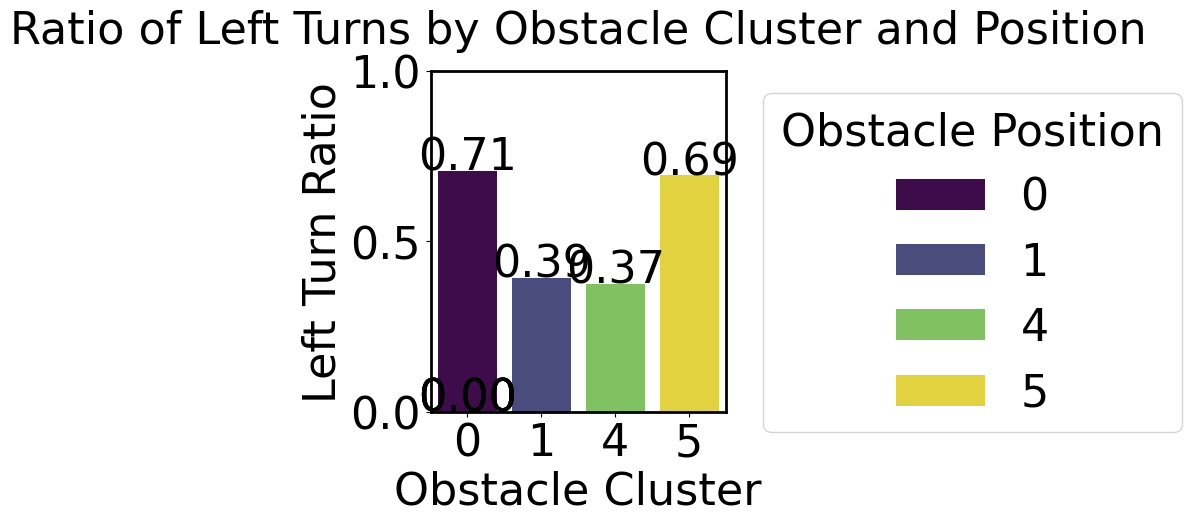

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is called 'df'
# Calculate left turn ratios by cluster and obstacle position
data = light_dark
data = data[data.task=='oadark']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15]
data = data[~data['obstacle_cluster'].isin([2,3])] 
turn_ratios = data.groupby(['obstacle_cluster'])['turn_direction_left_right'] \
                .apply(lambda x: (x == 'left').mean()) \
                .reset_index(name='left_turn_ratio')

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=turn_ratios, 
            x='obstacle_cluster', 
            y='left_turn_ratio', 
            hue='obstacle_cluster',
            palette='viridis')

# Customize the plot
plt.title('Ratio of Left Turns by Obstacle Cluster and Position', pad=20)
plt.xlabel('Obstacle Cluster')
plt.ylabel('Left Turn Ratio')
plt.ylim(0, 1)  # Since it's a ratio
plt.legend(title='Obstacle Position', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}", 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='center', 
                      xytext=(0, 10), 
                      textcoords='offset points')

plt.tight_layout()
plt.show()

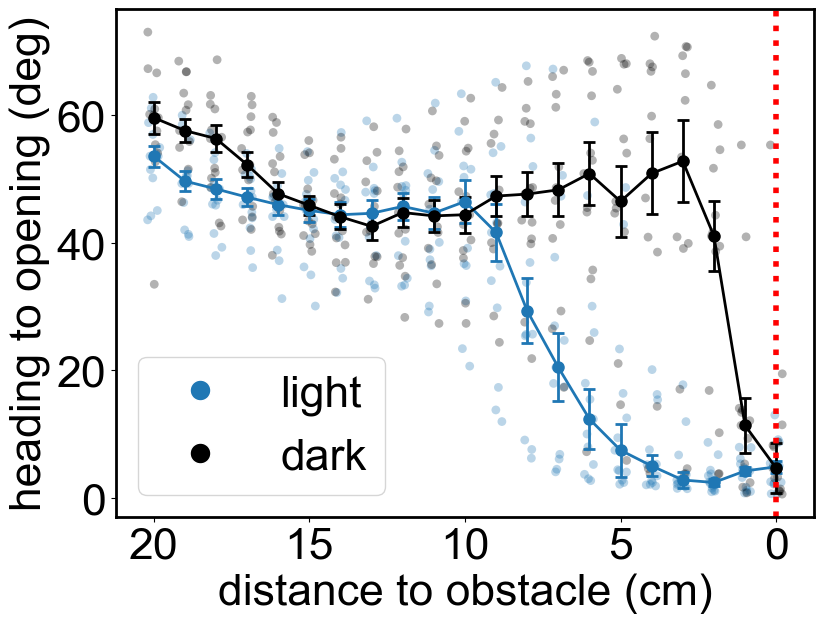

In [15]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 


# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.axvline(0, color='r', ls=':', linewidth=4)

# Legend with matching style
ax.legend(loc='lower left', fontsize=32, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)




plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "bold"

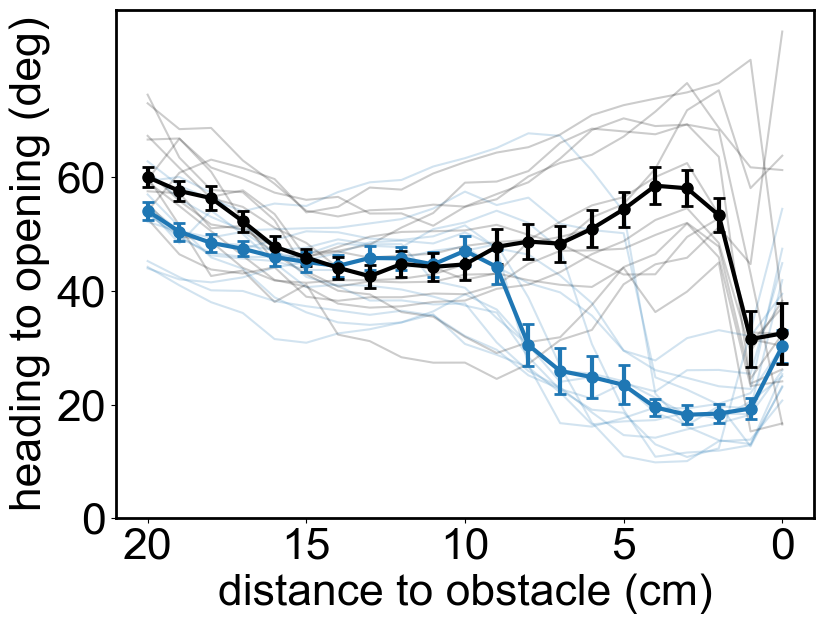

In [23]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32,
        'weight':'normal'}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 

# Storage for data
light_medians = []
dark_medians = []
light_lines = []  # For individual animal lines
dark_lines = []   # For individual animal lines

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.2, linewidth=1.5)
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.2, linewidth=1.5)

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)


# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
#ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "normal"

#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_to_opening_lines.pdf", 
            #pi=300, transparent=True)

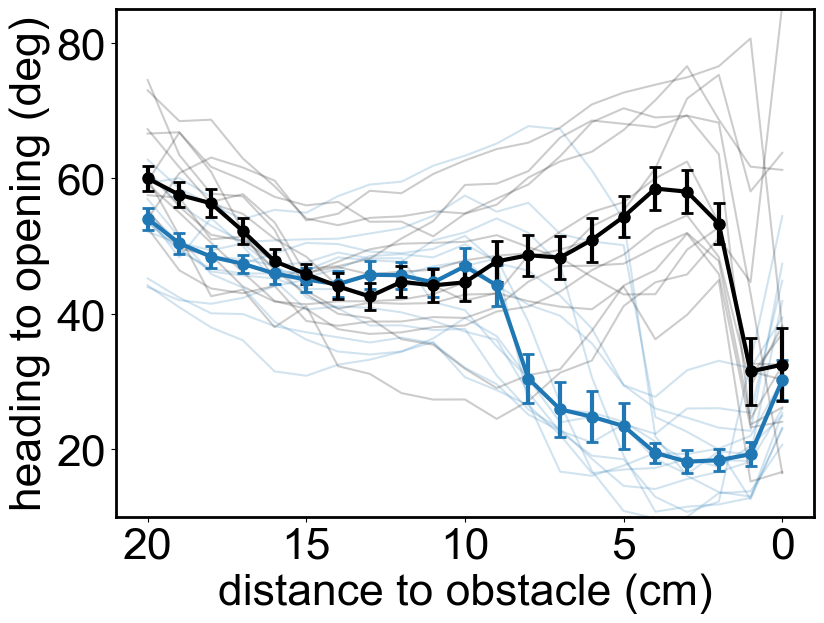

meta NOT subset; don't know how to subset; dropped


In [39]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32,
        'weight':'normal'}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 

def fill_nans_ffill(arr):
    """Fill NaN values using forward-fill only"""
    # Create a pandas Series for easy NaN handling
    series = pd.Series(arr)
    # Forward fill only
    filled = series.bfill()
    return filled.values

# Storage for data
light_medians = []
dark_medians = []
light_lines = []  # For individual animal lines
dark_lines = []   # For individual animal lines

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                interpolated = interpolater(xnew)
                
                # Check for NaNs and fill them with forward-fill only
                #if np.any(np.isnan(interpolated)):
                    #interpolated = fill_nans_ffill(interpolated)
                
                angle_array[i] = interpolated
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.2, linewidth=1.5)
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.2, linewidth=1.5)

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=3, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_ylim(10,85)
ax.set_yticks([20,40,60,80])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)


# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
#ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "normal"

fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_to_opening_lines.pdf", 
            dpi=300, transparent=True)

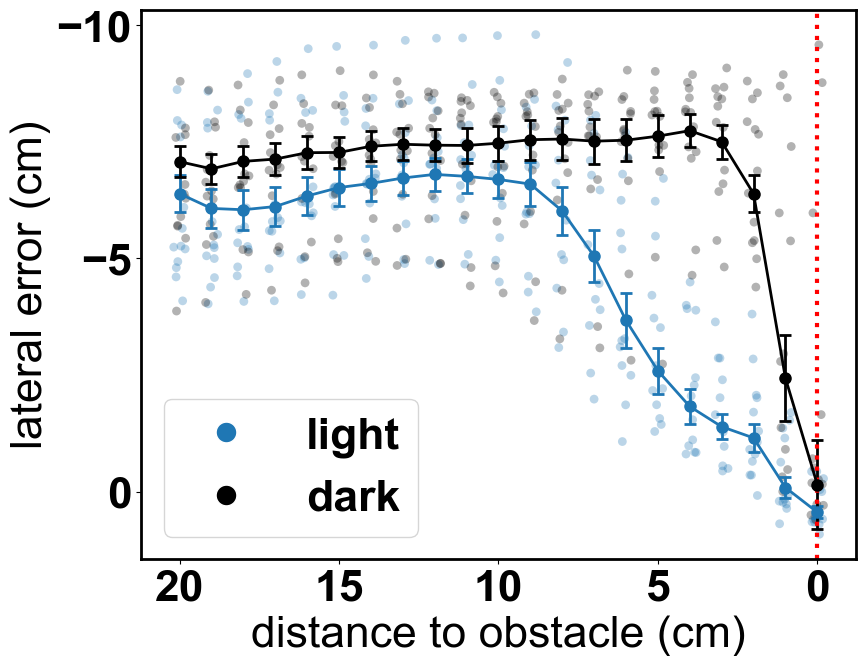

In [19]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SEM instead of SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

# Calculate number of non-nan observations for each distance point
light_n = np.sum(~np.isnan(light_medians), axis=0)
dark_n = np.sum(~np.isnan(dark_medians), axis=0)

# Calculate standard error of the mean
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(light_n)
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(dark_n)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-10,-5,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)
ax.invert_yaxis()

# Legend
markers = [plt.Line2D([0],[0], color='tab:blue', marker='o', linestyle=''),
           plt.Line2D([0],[0], color='black', marker='o', linestyle='')]
ax.legend(markers, ['light', 'dark'], numpoints=1, loc='lower left', fontsize=32)
# Update your legend call
ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()

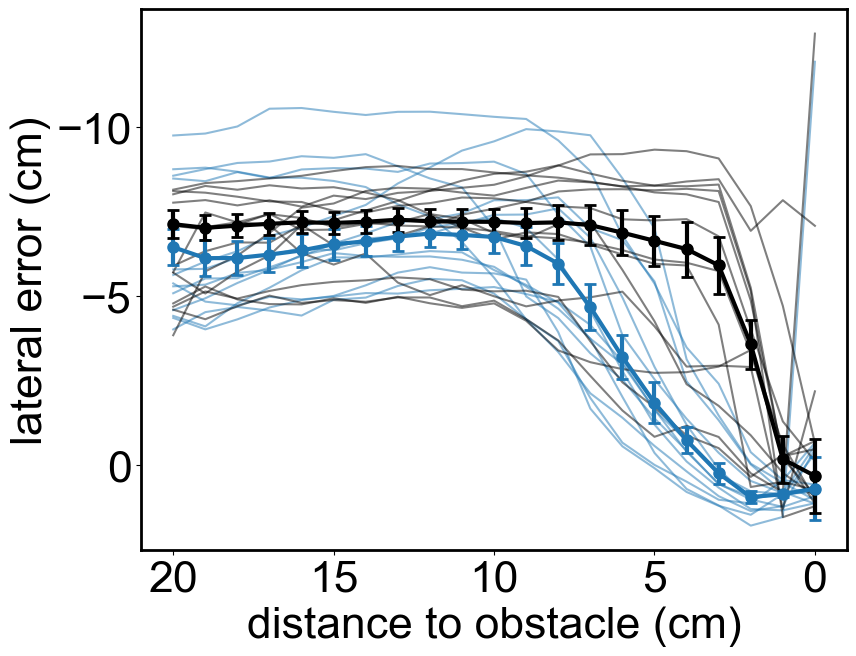

In [16]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'normal',
        'size': 21}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  

light_medians = []
dark_medians = []
light_lines = []  # Store individual animal lines
dark_lines = []   # Store individual animal lines

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)

# Calculate SEM instead of SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

# Calculate number of non-nan observations for each distance point
light_n = np.sum(~np.isnan(light_medians), axis=0)
dark_n = np.sum(~np.isnan(dark_medians), axis=0)

# Calculate standard error of the mean
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(light_n)
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(dark_n)

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.5, linewidth=1.5,linestyle = '-')
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.5, linewidth=1.5,linestyle = '-')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=3, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=3, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-10,-5,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')

ax.invert_yaxis()





plt.tight_layout()
plt.show()

#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\lateral_error_lines.pdf", 
#            dpi=300, transparent=True)

meta NOT subset; don't know how to subset; dropped


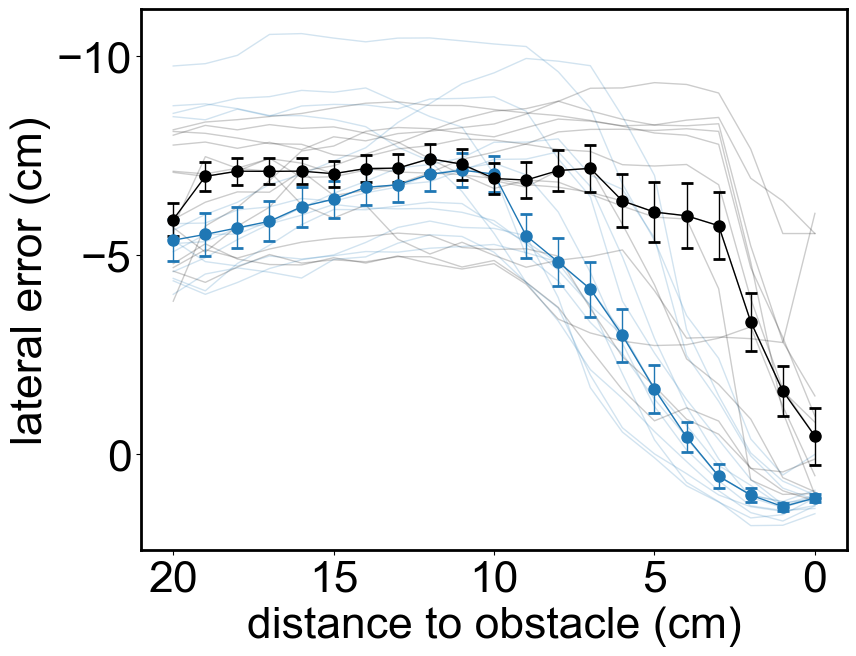

In [41]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'normal',
        'size': 21}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  

def fill_nans_ffill(arr):
    """Fill NaN values using forward-fill only"""
    # Create a pandas Series for easy NaN handling
    series = pd.Series(arr)
    # Forward fill only
    filled = series.ffill()
    return filled.values

light_medians = []
dark_medians = []
light_lines = []  # Store individual animal lines
dark_lines = []   # Store individual animal lines

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            interpolated = interpolater(xnew)
            
            # Check for NaNs and fill them with forward-fill only
            if np.any(np.isnan(interpolated)):
                interpolated = fill_nans_ffill(interpolated)
            
            angle_array[i] = interpolated
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                interpolated = interpolater(xnew)
                
                # Check for NaNs and fill them with forward-fill only
                if np.any(np.isnan(interpolated)):
                    interpolated = fill_nans_ffill(interpolated)
                
                animal_angle_array[i] = interpolated
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append(animal_median)
        else:
            dark_medians.append(animal_median)
            dark_lines.append(animal_median)

# Calculate SEM instead of SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

# Calculate number of non-nan observations for each distance point
light_n = np.sum(~np.isnan(light_medians), axis=0)
dark_n = np.sum(~np.isnan(dark_medians), axis=0)

# Calculate standard error of the mean
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(light_n)
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(dark_n)

# Plot individual animal lines first (so they're behind)
for animal_line in light_lines:
    ax.plot(xnew, animal_line, color='tab:blue', alpha=0.2, linewidth=1, linestyle='-')
for animal_line in dark_lines:
    ax.plot(xnew, animal_line, color='black', alpha=0.2, linewidth=1, linestyle='-')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, np.nanmedian(light_medians,axis = 0), yerr=light_sem,
           color='tab:blue', linewidth=1, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, np.nanmedian(dark_medians,axis = 0), yerr=dark_sem,
           color='black', linewidth=1, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-10,-5,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')

ax.invert_yaxis()

plt.tight_layout()
fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\lateral_error_lines.pdf", 
           dpi=300, transparent=True)
plt.show()

In [64]:
ob_ind

103

In [65]:
row[1]['ts_distance_from_target_port'][ob_ind:]

array([], dtype=object)

In [ ]:
goal_distance_from_target_port

In [66]:
row[1]['ts_distance_from_target_port'].shape

(98,)

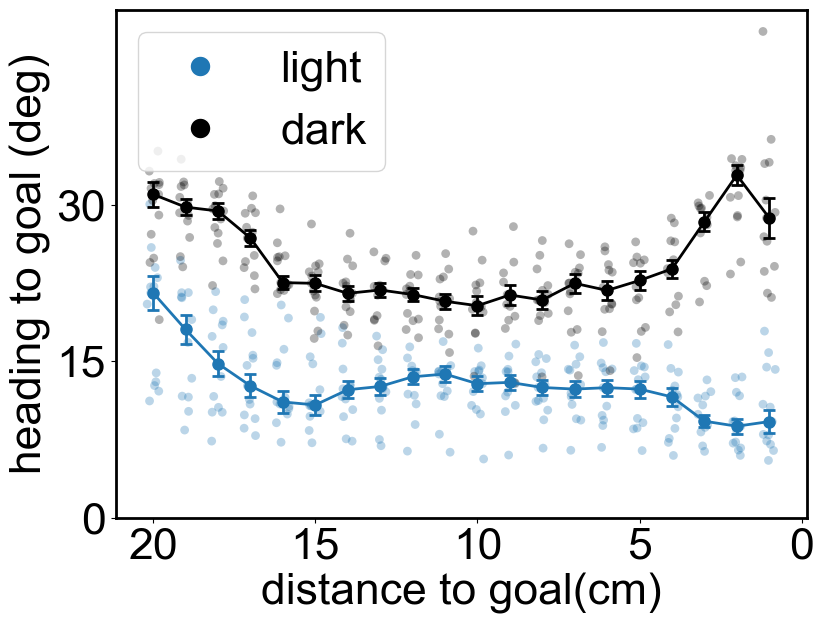

In [44]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))


# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,15,30])
ax.set_ylabel('heading to goal (deg)', fontsize=32)
ax.set_xlabel('distance to goal(cm)', fontsize=32)
#ax.axvline(0, color='r', ls=':', linewidth=2)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=32, framealpha=0.8)

# Grid lines for readability


plt.tight_layout()
plt.show()

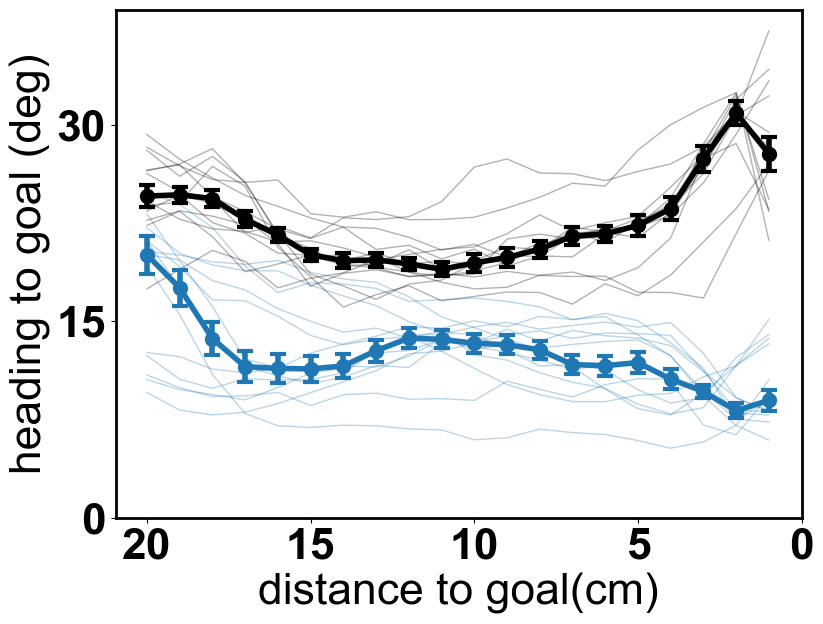

In [46]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 


# Storage for data
light_medians = []
dark_medians = []
light_lines = []  # For individual animal lines
dark_lines = []   # For individual animal lines

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append((xnew, animal_median, animal))
        else:
            dark_medians.append(animal_median)
            dark_lines.append((xnew, animal_median, animal))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual animal lines first (so they're behind)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.3, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.3, linewidth=1, zorder=1)

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=4, 
           marker='o', markersize=10, capsize=6, capthick=3,
           label='light', zorder=5)

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=4, 
           marker='o', markersize=10, capsize=6, capthick=3,
           label='dark', zorder=5)

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,15,30])
ax.set_ylabel('heading to goal (deg)', fontsize=32)
ax.set_xlabel('distance to goal(cm)', fontsize=32)
#ax.axvline(0, color='r', ls=':', linewidth=2)



plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\heading_to_goal_lines.pdf", 
#            dpi=300, transparent=True)
plt.show()

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


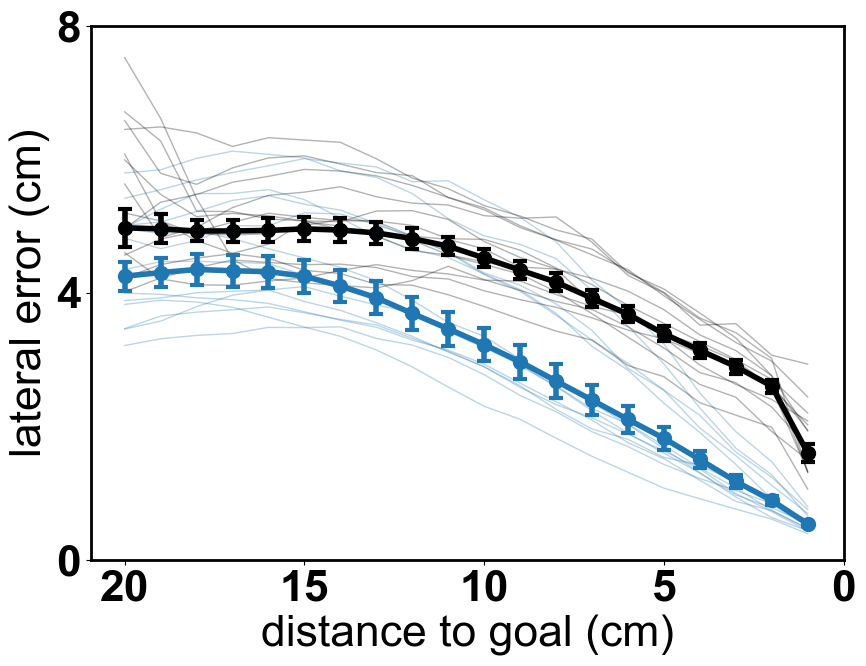

In [ ]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[~data['obstacle_cluster'].isin([2,3])] 


light_medians = []
dark_medians = []
light_lines = []  # Store individual animal lines
dark_lines = []   # Store individual animal lines

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_lateral_error_to_target_port'].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_lateral_error_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_lines.append((xnew, animal_median, animal))
        else:
            dark_medians.append(animal_median)
            dark_lines.append((xnew, animal_median, animal))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual animal lines first (so they're behind)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.3, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.3, linewidth=1, zorder=1)

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=4, marker='o', markersize=10,
           capsize=5, capthick=3, label='light', zorder=5)

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=4, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark', zorder=5)

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([8,4,0])
ax.set_ylabel('lateral error (cm)')

ax.set_xlabel('distance to goal (cm)')

plt.tight_layout()
fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\lateral_error_goal_lines.pdf", 
            dpi=300, transparent=True)
plt.show()

In [ ]:
fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_4\lateral_error_lines.pdf", 
            dpi=300, transparent=True)

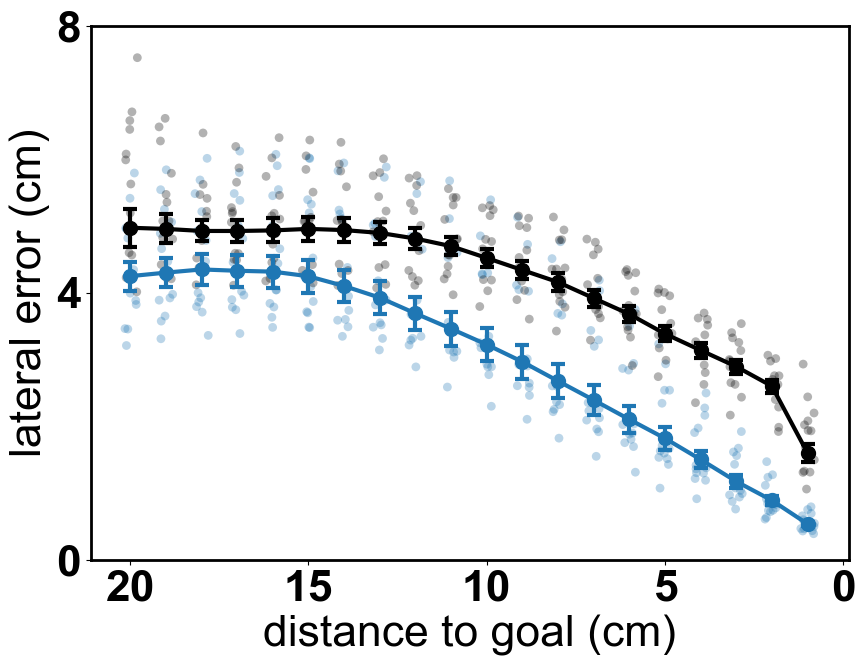

In [45]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_lateral_error_to_target_port'].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_lateral_error_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)


light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([8,4,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to goal (cm)')





plt.tight_layout()
plt.show()

In [90]:
light_dark.tortuosity = light_dark.tortuosity.round(2) 

In [4]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})

In [28]:
def ts_calculate_relative_distance2(df):
    """calculates relative distance of nose to point on obstacle using first occurrence of each x position"""
    for direction, direction_frame in df.groupby(['odd']):
        for ind, row in direction_frame.iterrows():  
            if direction == 'right':
                try:
                    nose_x = row['ts_nose_x_cm']
                    nose_y = row['ts_nose_y_cm']
                    distances = []
                    processed_x = set()  # Track seen x positions
                    obstacle_x = np.mean([row['gt_obstacleTR_x_cm'], row['gt_obstacleBR_x_cm']])
                    
                    for i, x in enumerate(nose_x):
                        if x not in processed_x:  # Only process first occurrence
                            processed_x.add(x)
                            # Calculate x distance with sign
                            distance = x - obstacle_x  # Negative when left of obstacle
                            distances.append(distance)
                            
                except (IndexError, KeyError):
                    distances = [np.nan]
                
                df.at[ind, 'ts_distance_from_edge'] = np.array(distances).astype(object)
                df.at[ind, 'ts_len_distance_from_edge'] = len(distances)
                
            elif direction == 'left':
                try:
                    nose_x = row['ts_nose_x_cm']
                    nose_y = row['ts_nose_y_cm']
                    distances = []
                    processed_x = set()  # Track seen x positions
                    obstacle_x = np.mean([row['gt_obstacleTL_x_cm'], row['gt_obstacleBL_x_cm']])
                    
                    for i, x in enumerate(nose_x):
                        if x not in processed_x:  # Only process first occurrence
                            processed_x.add(x)
                            # Calculate x distance with sign
                            distance = obstacle_x - x  # Negative when right of obstacle
                            distances.append(distance)
                            
                except (IndexError, KeyError):
                    distances = [np.nan]
                
                df.at[ind, 'ts_distance_from_edge'] = np.array(distances).astype(object)
                df.at[ind, 'ts_len_distance_from_edge'] = len(distances)
    
    return df

In [13]:
light_bins


array([ 0.00017865,  0.9525342 ,  1.90488975,  2.8572453 ,  3.80960085,
        4.76195641,  5.71431196,  6.66666751,  7.61902306,  8.57137862,
        9.52373417, 10.47608972, 11.42844527, 12.38080083, 13.33315638,
       14.28551193, 15.23786748, 16.19022304, 17.14257859, 18.09493414,
       19.04728969, 19.99964525])

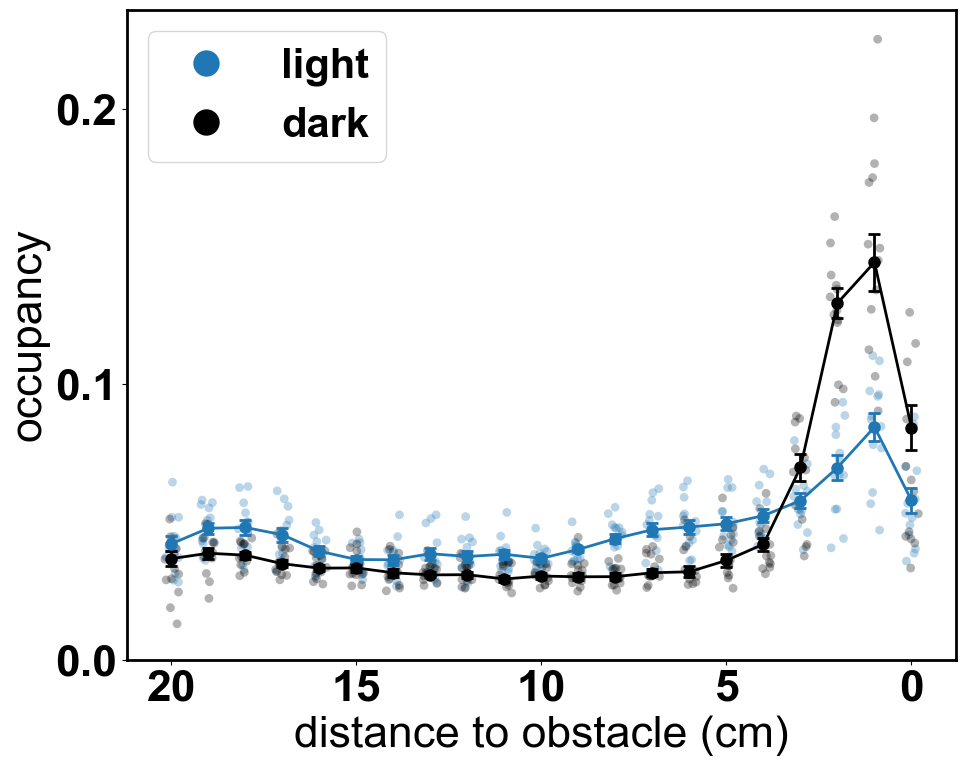

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [92]:
xnew = np.arange(0, 21, 1)
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
#data = data[data.avg_lateral_error<0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
ts_calculate_relative_distance2(light)
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []  # To store individual animal points

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
ts_calculate_relative_distance2(dark)
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []  # To store individual animal points

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2])
ax.set_ylabel('occupancy', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.invert_xaxis()

# Legend

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)

plt.tight_layout()
plt.show()
fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\distance_to_obstacle.pdf",dpi = 300, transparent=True)

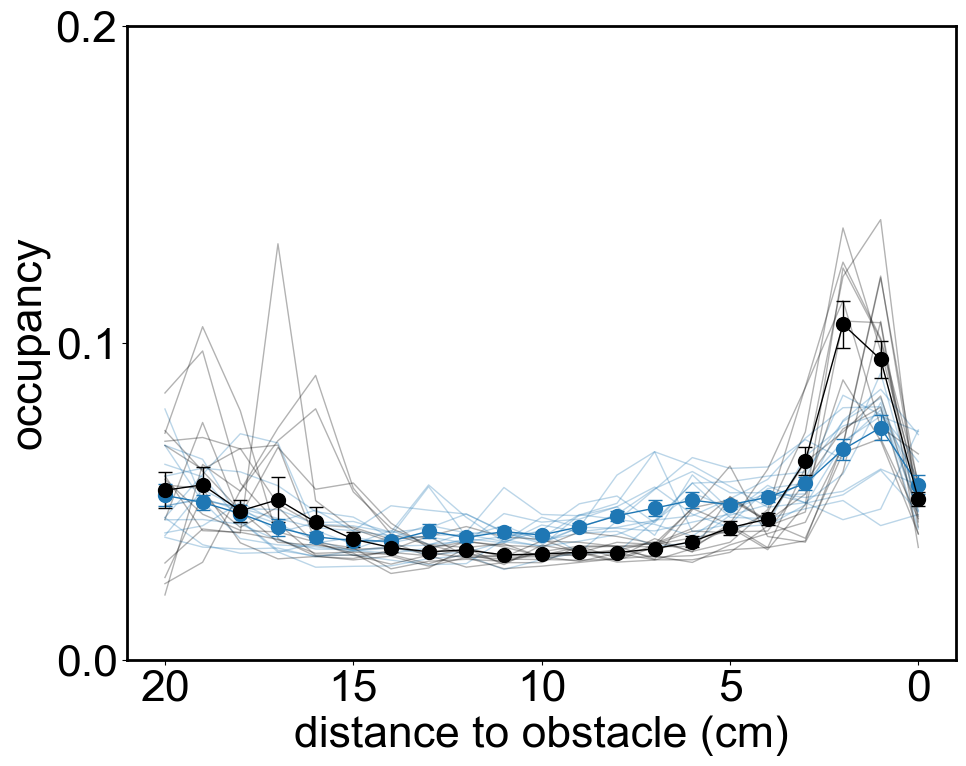

In [72]:
xnew = np.arange(0, 21, 1)
data = pd.concat([light_dark]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
#data = data[data.avg_lateral_error<0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'normal', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']

light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_lines = []  # To store individual animal lines

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    # Store data for line plots (no jitter needed for lines)
    light_lines.append((xnew, prob, ani))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_lines = []  # To store individual animal lines

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    # Store data for line plots (no jitter needed for lines)
    dark_lines.append((xnew, prob, ani))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.3, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.3, linewidth=1, zorder=1)

# Plot mean lines with SEM error bars (thicker for visibility)
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=1,
           markersize=10, capsize=5, capthick=1,
           label='light', zorder=5)

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=1,
           markersize=10, capsize=5, capthick=1,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2])
ax.set_ylabel('occupancy', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.invert_xaxis()

plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\distance_to_obstacle_lines.pdf",dpi = 300, transparent=True)
plt.show()

In [70]:
np.asanyarray(light_lines)[:,1]

array([array([0.04842135, 0.09047147, 0.06328755, 0.0695172 , 0.06088065,
              0.0604559 , 0.06385389, 0.0538015 , 0.0438907 , 0.0339799 ,
              0.03171457, 0.02859975, 0.03298881, 0.03199773, 0.02973241,
              0.02959083, 0.02930766, 0.03412148, 0.0438907 , 0.05776582,
              0.06173014])                                               ,
       array([0.04591903, 0.04242659, 0.05031691, 0.04772992, 0.04462553,
              0.04501358, 0.05587893, 0.04333204, 0.05173975, 0.04928211,
              0.0408744 , 0.03725262, 0.04501358, 0.05523218, 0.040357  ,
              0.04372009, 0.04333204, 0.04022765, 0.04837667, 0.05018756,
              0.07916182])                                               ,
       array([0.04138668, 0.07987172, 0.07956628, 0.06994502, 0.05696396,
              0.05085522, 0.04551008, 0.04413561, 0.04184484, 0.04047037,
              0.04260843, 0.03695785, 0.03833232, 0.03527795, 0.03375076,
              0.03451436, 0.0357361 

In [69]:
np.nanmedian(np.asanyarray(light_lines)[:,1],axis=0)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [62]:
light_lines[:,1]

TypeError: list indices must be integers or slices, not tuple

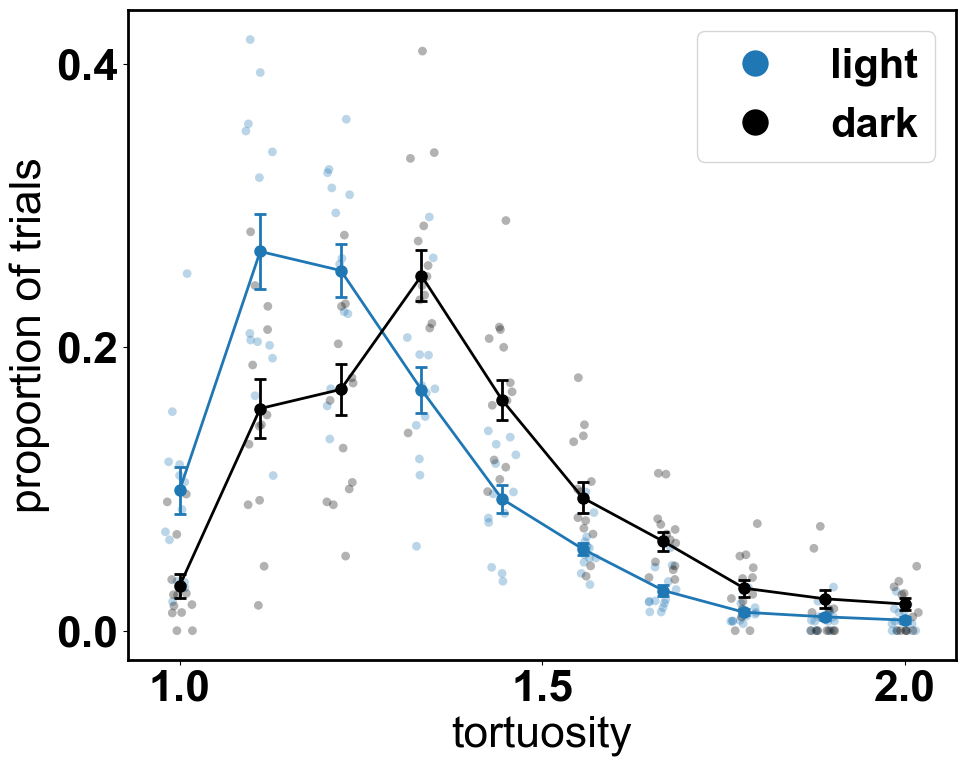

<Figure size 640x480 with 0 Axes>

In [76]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  


fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']

light_dist = (light.tortuosity.round(2).to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

light_counts, light_bins = np.histogram(light_dist, bins=10,range=(1,2))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.round(2).to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    counts, bins = np.histogram(ani_light_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.round(2).to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=10,range=(1,2))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.round(2).to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4])
ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('tortuosity', fontweight='normal')     # Not bold

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')



# Legend
ax.legend(loc='upper right', framealpha=0.8)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=30, framealpha=0.8)


plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\tortuosity.pdf",dpi = 300, transparent=True)

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


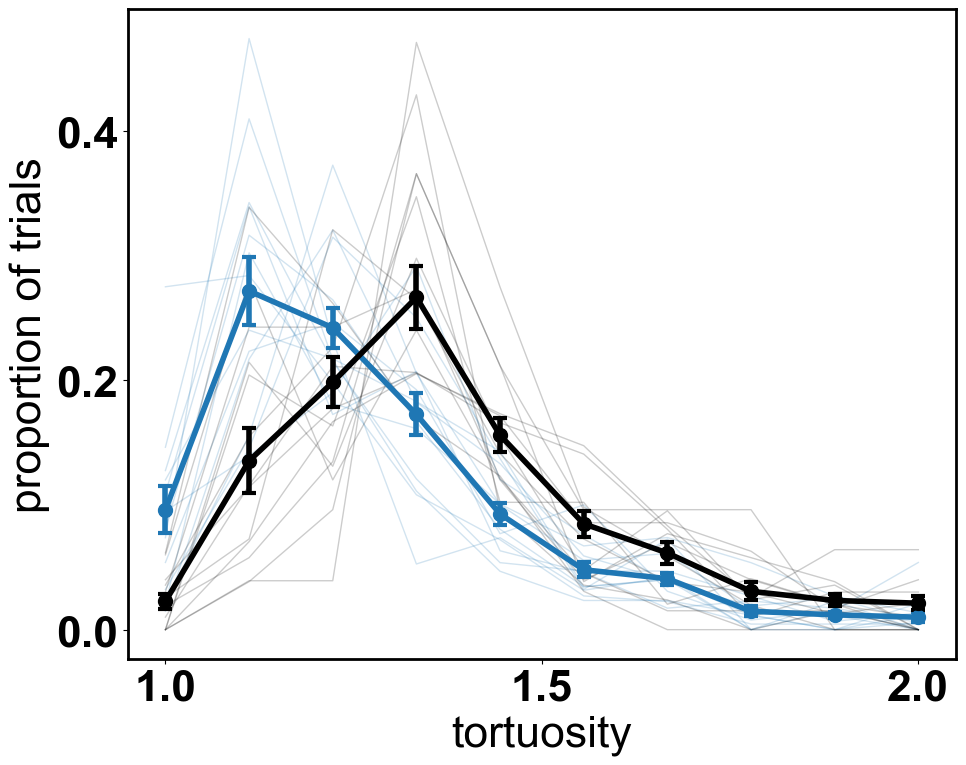

In [ ]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=15]
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance<=15] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

light_counts, light_bins = np.histogram(light_dist, bins=10,range=(1,2))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_lines = []  # Changed to store lines
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    counts, bins = np.histogram(ani_light_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Store data for line plots (no jitter needed for lines)
    light_lines.append((xnew, prob, ani))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=10,range=(1,2))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_lines = []  # Changed to store lines
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Store data for line plots (no jitter needed for lines)
    dark_lines.append((xnew, prob, ani))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual animal lines first (so they're behind the mean lines)
for x, y, animal in light_lines:
    ax.plot(x, y, color='tab:blue', alpha=0.2, linewidth=1, zorder=1)
    
for x, y, animal in dark_lines:
    ax.plot(x, y, color='black', alpha=0.2, linewidth=1, zorder=1)

# Plot mean lines with SEM error bars (thicker for visibility)
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='light', zorder=5)

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=4,
           markersize=10, capsize=5, capthick=3,
           label='dark', zorder=5)

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4])
ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('tortuosity', fontweight='normal')     # Not bold

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')



plt.tight_layout()
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\tortuosity_lines.pdf",dpi = 300, transparent=True)
plt.show()

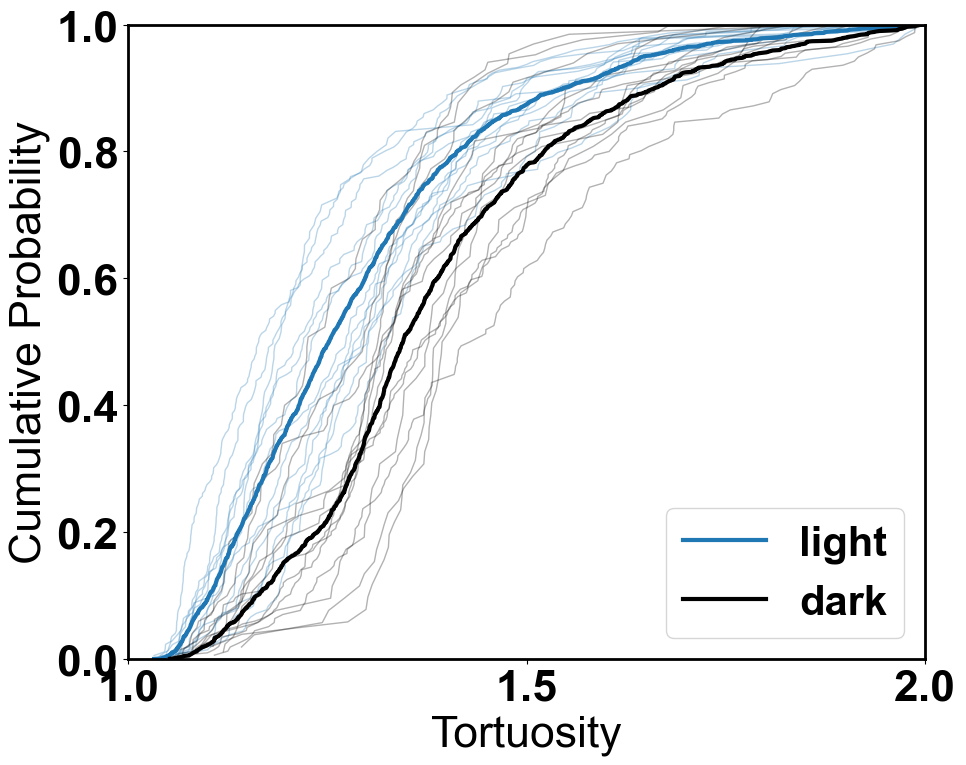

In [24]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=15]
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance<=15] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']

light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

# Create CDF for light condition
light_sorted = np.sort(light_dist)
light_cdf = np.arange(1, len(light_sorted) + 1) / len(light_sorted)

# Process individual animals for light condition
light_cdf_individual = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    if len(ani_light_dists) > 0:
        ani_sorted = np.sort(ani_light_dists)
        ani_cdf = np.arange(1, len(ani_sorted) + 1) / len(ani_sorted)
        light_cdf_individual.append((ani_sorted, ani_cdf))
        light_mean.append(np.nanmean(ani_light_dists))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

# Create CDF for dark condition
dark_sorted = np.sort(dark_dist)
dark_cdf = np.arange(1, len(dark_sorted) + 1) / len(dark_sorted)

# Process individual animals for dark condition
dark_cdf_individual = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    if len(ani_dark_dists) > 0:
        ani_sorted = np.sort(ani_dark_dists)
        ani_cdf = np.arange(1, len(ani_sorted) + 1) / len(ani_sorted)
        dark_cdf_individual.append((ani_sorted, ani_cdf))
        dark_mean.append(np.nanmean(ani_dark_dists))

# Plot individual animal CDFs first (so they're behind the mean lines)
for x_vals, y_vals in light_cdf_individual:
    ax.plot(x_vals, y_vals, color='tab:blue', alpha=0.3, linewidth=1)

for x_vals, y_vals in dark_cdf_individual:
    ax.plot(x_vals, y_vals, color='black', alpha=0.3, linewidth=1)

# Plot mean CDF lines
ax.plot(light_sorted, light_cdf, color='tab:blue', linewidth=3, label='light')
ax.plot(dark_sorted, dark_cdf, color='black', linewidth=3, label='dark')

# Formatting
ax.set_xlim(1, 2)
ax.set_ylim(0, 1)
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel('Cumulative Probability', fontweight='normal')
ax.set_xlabel('Tortuosity', fontweight='normal')

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='tab:blue', linewidth=3, label='light'),
    Line2D([0], [0], color='black', linewidth=3, label='dark')
]

ax.legend(handles=legend_handles, loc='lower right', fontsize=30, framealpha=0.8)

plt.tight_layout()
plt.show()

In [26]:
# Complete statistical analysis
def run_complete_analysis(light, dark):
    print("=== TORTUOSITY STATISTICAL ANALYSIS ===\n")
    
    # Get distributions
    light_dist = light.tortuosity.to_numpy()
    light_dist = light_dist[np.where((light_dist <= 2))]
    dark_dist = dark.tortuosity.to_numpy()
    dark_dist = dark_dist[np.where((dark_dist <= 2))]
    
    print(f"Light condition: n = {len(light_dist)} trials")
    print(f"Dark condition: n = {len(dark_dist)} trials")
    print(f"Light median ± SD: {np.median(light_dist):.4f} ± {np.std(light_dist, ddof=1):.4f}")
    print(f"Dark median ± SD: {np.median(dark_dist):.4f} ± {np.std(dark_dist, ddof=1):.4f}\n")
    
    # Paired analysis by animal
    light_medians, dark_medians = [], []
    animal_pairs = []
    
    # Find animals with data in both conditions
    light_animals = set(light['animal'].unique())
    dark_animals = set(dark['animal'].unique())
    common_animals = light_animals.intersection(dark_animals)
    
    for animal in common_animals:
        light_vals = light[light['animal'] == animal].tortuosity.to_numpy()
        light_vals = light_vals[np.where((light_vals <= 2))]
        dark_vals = dark[dark['animal'] == animal].tortuosity.to_numpy()
        dark_vals = dark_vals[np.where((dark_vals <= 2))]
        
        if len(light_vals) > 0 and len(dark_vals) > 0:
            light_medians.append(np.median(light_vals))
            dark_medians.append(np.median(dark_vals))
            animal_pairs.append(animal)
    
    print(f"Animals with paired data: {len(animal_pairs)}\n")
    
    if len(animal_pairs) >= 3:  # Minimum for medianingful paired test
        # Normality test
        differences = [light_medians[i] - dark_medians[i] for i in range(len(light_medians))]
        _, p_normality = stats.shapiro(differences)
        print(f"1. Normality of differences: p = {p_normality:.4f}")
        
        # Paired test selection
        if p_normality > 0.05:
            t_stat, p_paired = stats.ttest_rel(light_medians, dark_medians)
            print(f"2. Paired t-test: t({len(animal_pairs)-1}) = {t_stat:.4f}, p = {p_paired:.4f}")
            test_used = "Paired t-test"
        else:
            wilcoxon_stat, p_paired = stats.wilcoxon(light_medians, dark_medians)
            print(f"2. Wilcoxon signed-rank test: statistic = {wilcoxon_stat:.4f}, p = {p_paired:.4f}")
            test_used = "Wilcoxon signed-rank test"
        
        # Effect size
        cohens_d = (np.median(light_medians) - np.median(dark_medians)) / np.std(differences, ddof=1)
        print(f"3. Cohen's d (paired): {cohens_d:.4f}")
    
    # KS test on full distributions
    ks_stat, p_ks = stats.ks_2samp(light_dist, dark_dist)
    print(f"4. Kolmogorov-Smirnov test: D = {ks_stat:.4f}, p = {p_ks:.4f}")
    
    # Mann-Whitney U test (non-paired alternative)
    u_stat, p_mw = stats.mannwhitneyu(light_dist, dark_dist, alternative='two-sided')
    print(f"5. Mann-Whitney U test: U = {u_stat:.4f}, p = {p_mw:.4f}")
    
    return {
        'paired_p_value': p_paired if len(animal_pairs) >= 3 else None,
        'ks_p_value': p_ks,
        'mann_whitney_p_value': p_mw,
        'test_used': test_used if len(animal_pairs) >= 3 else 'Insufficient paired data',
        'n_paired_animals': len(animal_pairs)
    }

# Run the analysis
results = run_complete_analysis(light, dark)

=== TORTUOSITY STATISTICAL ANALYSIS ===

Light condition: n = 2104 trials
Dark condition: n = 1367 trials
Light median ± SD: 1.2516 ± 0.1810
Dark median ± SD: 1.3451 ± 0.1907

Animals with paired data: 9

1. Normality of differences: p = 0.3238
2. Paired t-test: t(8) = -3.1024, p = 0.0146
3. Cohen's d (paired): -1.0771
4. Kolmogorov-Smirnov test: D = 0.2821, p = 0.0000
5. Mann-Whitney U test: U = 975491.0000, p = 0.0000


NameError: name 'mon' is not defined

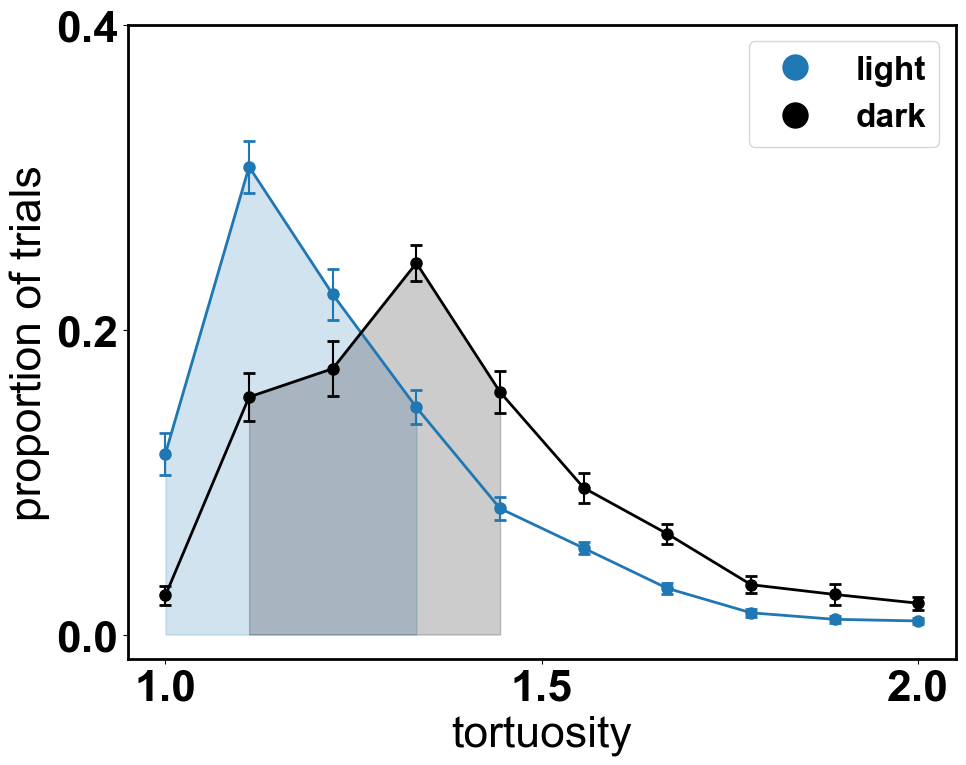

In [131]:
plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',
    'savefig.transparent': True
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

light_counts, light_bins = np.histogram(light_dist, bins=10, range=(1,2))
light_hist = (light_counts / sum(light_counts))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=10, range=(1,2))
dark_hist = (dark_counts / sum(dark_counts))

# Calculate SEM
light_prob = np.asarray([np.histogram(ani_df.tortuosity.to_numpy(), bins=10, range=(1,2))[0] / 
                        np.histogram(ani_df.tortuosity.to_numpy(), bins=10, range=(1,2))[0].sum()
                        for ani, ani_df in light.groupby(['animal'])])
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

dark_prob = np.asarray([np.histogram(ani_df.tortuosity.to_numpy(), bins=10, range=(1,2))[0] / 
                       np.histogram(ani_df.tortuosity.to_numpy(), bins=10, range=(1,2))[0].sum()
                       for ani, ani_df in dark.groupby(['animal'])])
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot mean lines with SEM error bars
light_line, = ax.plot(xnew, light_hist, '-o', color='tab:blue', linewidth=2,
                     markersize=8, label='light')
dark_line, = ax.plot(xnew, dark_hist, '-o', color='black', linewidth=2,
                    markersize=8, label='dark')

# Add error bars separately (for proper shading)
ax.errorbar(xnew, light_hist, yerr=light_sem, fmt='none', 
            color='tab:blue', capsize=4, capthick=2)
ax.errorbar(xnew, dark_hist, yerr=dark_sem, fmt='none', 
            color='black', capsize=4, capthick=2)

# Shade regions under the curves
# For light (blue) between 1 and 1.33
light_mask = (xnew >= 1) & (xnew <= 1.44)
ax.fill_between(xnew[light_mask], 0, light_hist[light_mask], 
                color='tab:blue', alpha=0.2)

# For dark (black) between 1.11 and 1.44
dark_mask = (xnew >= 1.11) & (xnew <= 1.55)
ax.fill_between(xnew[dark_mask], 0, dark_hist[dark_mask], 
                color='black', alpha=0.2)

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4])
ax.set_ylabel('proportion of trials', fontweight='normal')
ax.set_xlabel('tortuosity', fontweight='normal')

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Custom legend
from matplotlib.patches import Patch
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20),
 
]

ax.legend(handles=legend_handles, loc='upper right', fontsize=24, framealpha=0.8)

plt.tight_layout()
plt.show()

In [104]:
def get_median_trajectory(df, x_key: str, y_key: str, 
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate median trajectory by interpolating y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both median and all interpolated trajectories
    
    Returns:
    - Median trajectory (and optionally all trajectories)
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
   
    
   ## Set distance bins based on turn direction and start position
   #if turn_direction == 'left' and start_position == 'bottom':
   #    distance_bins = np.arange(9, 50, 1)    # Left turns from bottom left
   #elif turn_direction == 'right' and start_position == 'bottom':
   #    distance_bins = np.arange(45, 0, -1)   # Right turns from bottom right
   #elif turn_direction == 'left' and start_position == 'top':
   #    distance_bins = np.arange(45, 0, -1) 
   #elif turn_direction == 'right' and start_position == 'top':
   #    distance_bins = np.arange(9, 50, 1) 

        # Set distance bins based on turn direction and start position
 
    if turn_direction == 'left':
        distance_bins = np.arange(55, 13, -1)    # Left turns from bottom left
    elif turn_direction == 'right':
        distance_bins = np.arange(7, 50, 1)   # Right turns from bottom right
  
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan  # Initialize with NaNs
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        # Remove duplicate x-values (keep first occurrence)
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        # Only interpolate if we have at least 2 points
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    # Calculate median trajectory
    median_trajectory = np.nanmean(trajectory_matrix, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_median = pd.Series(median_trajectory)
    valid_median.fillna(method='bfill', inplace=True)
    valid_median.fillna(method='ffill', inplace=True)
    median_trajectory = valid_median.to_numpy()
    
    if return_matrix:
        return median_trajectory, trajectory_matrix
    else:
        return median_trajectory,distance_bins

In [ ]:

first_nose_y,first_nose_x=get_median_trajectory(first_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

sec_nose_y,sec_nose_x=get_median_trajectory(sec_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')


array([1.        , 1.11111111, 1.22222222, 1.33333333, 1.44444444,
       1.55555556, 1.66666667, 1.77777778, 1.88888889, 2.        ])

In [100]:
light_dark.tortuosity = light_dark.tortuosity.round(1) 

KeyError: '[50] not in index'

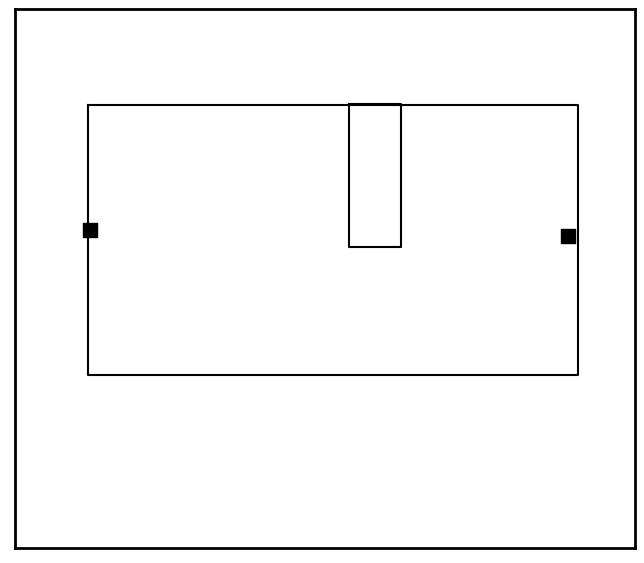

In [12]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oa')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')]
#light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = (get_median_trajectory(light,'ts_nose_x_cm',50))
light_nose_y = (get_median_trajectory(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(15)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')


ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\one_one.three_tortuosity.pdf",dpi = 300, transparent=True)

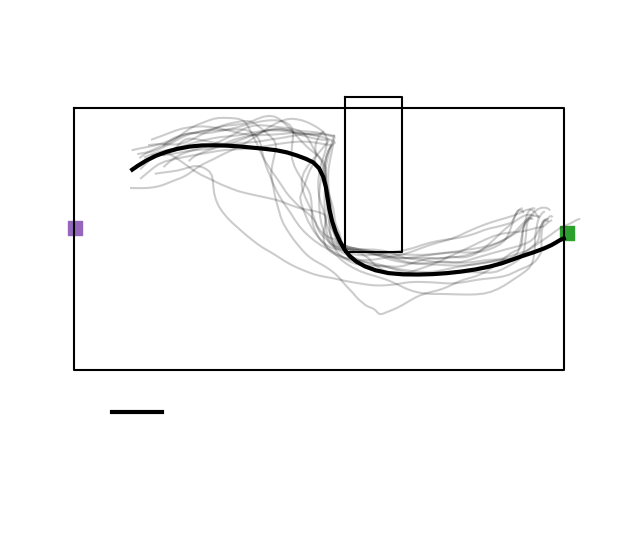

In [141]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oadark')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')&(light_dark.tortuosity.between(1.1,1.4))]
#light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3,c='black')
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(15)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    #x,y = row.ts_nose_x_cm,row.ts_nose_y_cm
    ax.plot(x,y,alpha = .2 ,c = 'black')


ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
fig.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\one.one_one.four_tortuosity.pdf",dpi = 300, transparent=True)

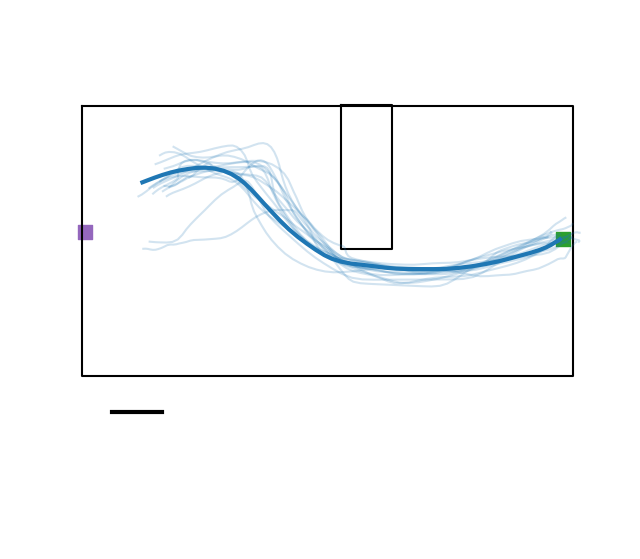

In [101]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oa')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')&(light_dark.tortuosity.between(1.1,1.2))]
#light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(15)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')


ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

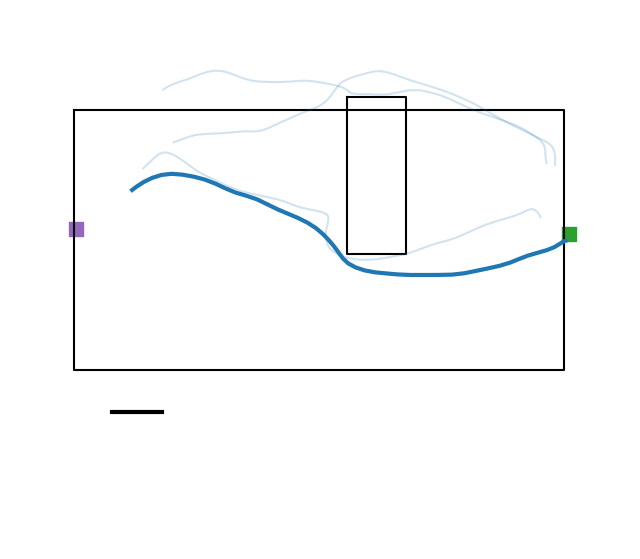

In [103]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oadark')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')&(light_dark.tortuosity.between(1.1,1.2))]
#light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')


ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ValueError: a must be greater than 0 unless no samples are taken

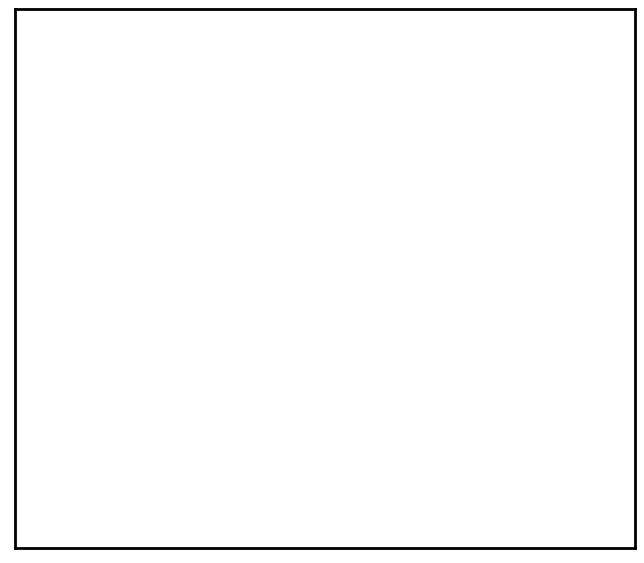

In [99]:
fig,ax = plt.subplots(1,1,figsize=(8,7),)
light = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oa')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')&(light_dark.tortuosity ==1.3)]
#light = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
ax.set_xticks([])
ax.set_yticks([])
plot_arena(light,ax)
ob_x,ob_y = plot_orginal_obstacle(light,ax,5)
light_nose_x = smooth(get_median_of_df(light,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light,'ts_nose_y_cm',50))
ax.plot(light_nose_x,light_nose_y,linewidth = 3)
light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(15)
for ind,row in light_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax.plot(x,y,alpha = .2 ,c = 'tab:blue')


ax.plot((10,15),(38,38),c ='black', linewidth = 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_figures\tort_low_light_traces_median_traces.pdf",dpi = 300, transparent=True)

In [119]:
np.linspace(1,2,4)

array([1.        , 1.33333333, 1.66666667, 2.        ])

<AxesSubplot: >

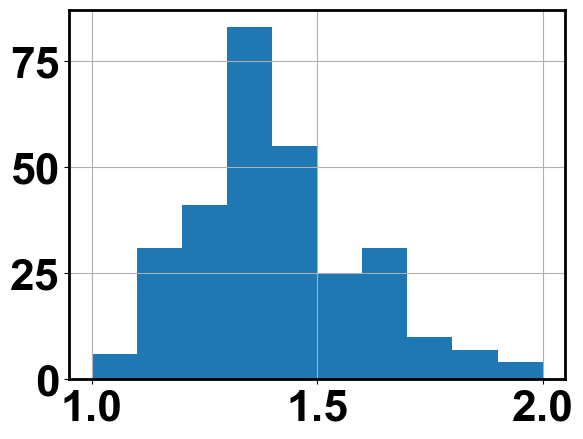

In [118]:
dark = light_dark[(light_dark.obstacle_cluster == 1)&(light_dark.avg_lateral_error <=0)&(light_dark.task =='oadark')&(light_dark.intial_distance >=15)&(light_dark.obstacle_cross == True)&(light_dark.odd =='left')]
dark.tortuosity.hist(range = (1,2))

<AxesSubplot: >

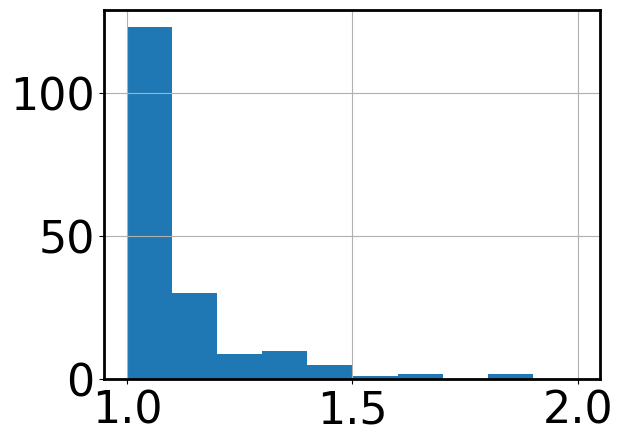

In [23]:
light.tortuosity.hist(range = (1,2))

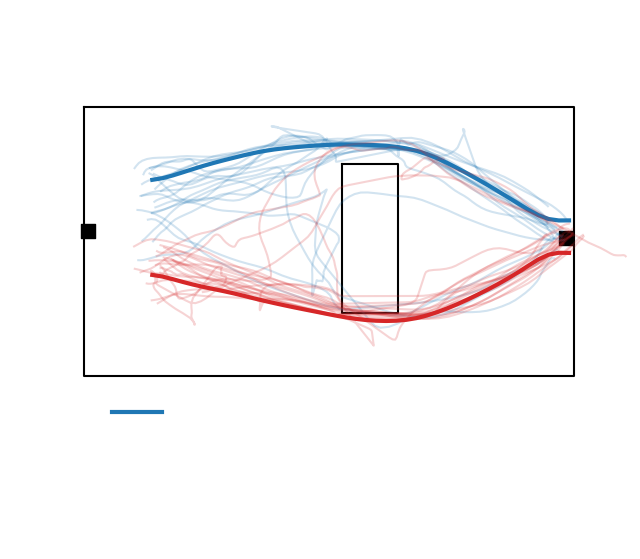

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 3) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.odd == 'left') &
                   (light_dark.start == 'top')  
                   ]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')


light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
   
 
    
    ax.plot(x, y, alpha=0.2, c='tab:blue')




ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'tab:blue')
ax.plot((10,15), (38,38), c='tab:blue', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

light = light_dark[(light_dark.obstacle_cluster == 3) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.odd == 'left') &
                   (light_dark.start == 'bottom')  ]

ax.set_xticks([])
ax.set_yticks([])


light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')


light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
   
 
    
    ax.plot(x, y, alpha=0.2, c='tab:red')

ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'tab:red')
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\middle_median_traces.pdf",dpi = 300, transparent=True)

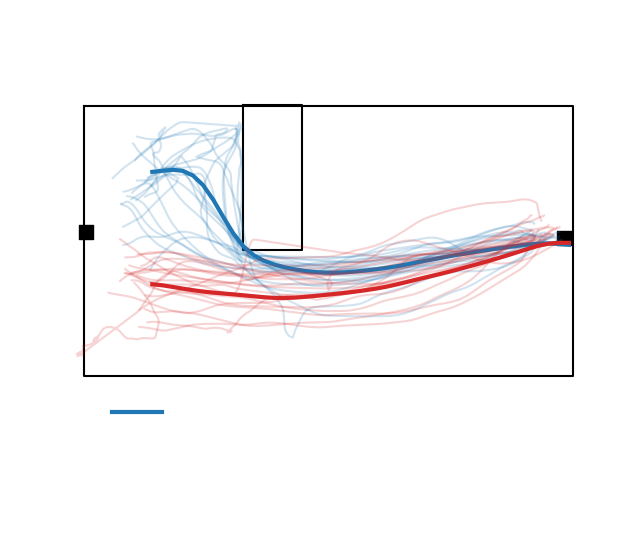

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 0) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')


light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
   
 
    
    ax.plot(x, y, alpha=0.2, c='tab:blue')




ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'tab:blue')
ax.plot((10,15), (38,38), c='tab:blue', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

light = light_dark[(light_dark.obstacle_cluster == 0) & 
                   (light_dark.avg_lateral_error >= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])


light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')


light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
   
 
    
    ax.plot(x, y, alpha=0.2, c='tab:red')

ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'tab:red')

fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\short_median_traces.pdf",dpi = 300, transparent=True)

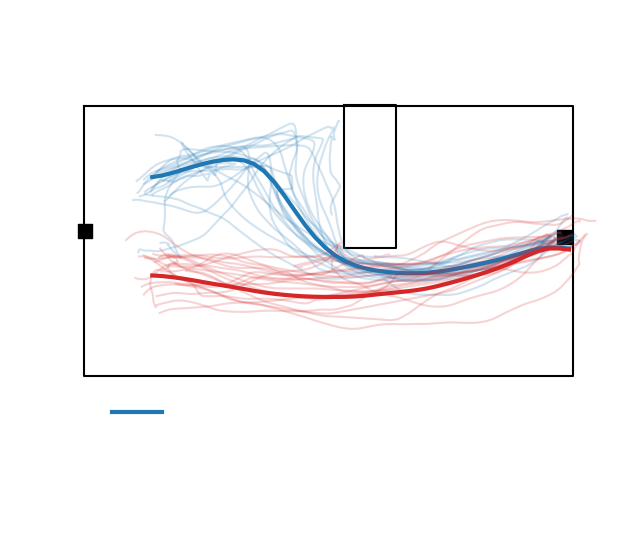

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')


light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
   
 
    
    ax.plot(x, y, alpha=0.2, c='tab:blue')




ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'tab:blue')
ax.plot((10,15), (38,38), c='tab:blue', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error >= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])


light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')


light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
   
 
    
    ax.plot(x, y, alpha=0.2, c='tab:red')

ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'tab:red')

fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\long_median_traces.pdf",dpi = 300, transparent=True)

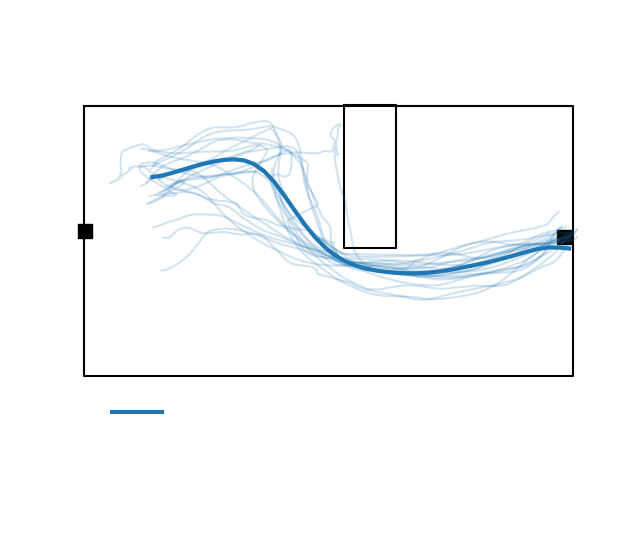

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')


light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
   
 
    
    ax.plot(x, y, alpha=0.2, c='tab:blue')




ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'tab:blue')
ax.plot((10,15), (38,38), c='tab:blue', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\light_trials.pdf",dpi = 300, transparent=True)

In [ ]:
light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')

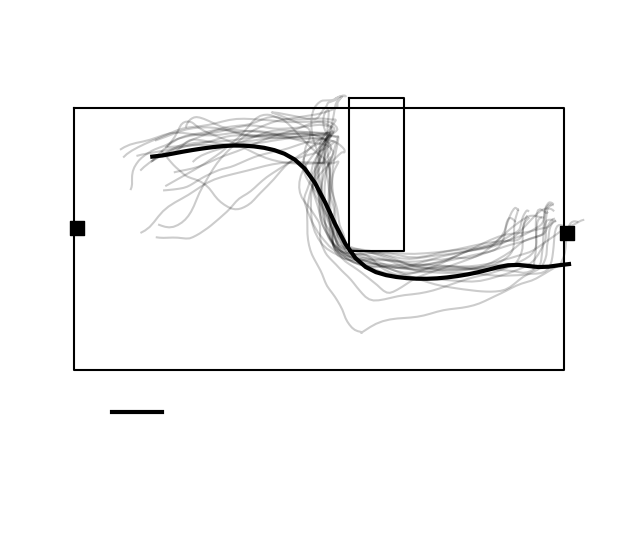

In [199]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oadark') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')


light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
   
 
    
    ax.plot(x, y, alpha=0.2, c='black')
ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'black')
ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\dark_trials.pdf",dpi = 300, transparent=True)

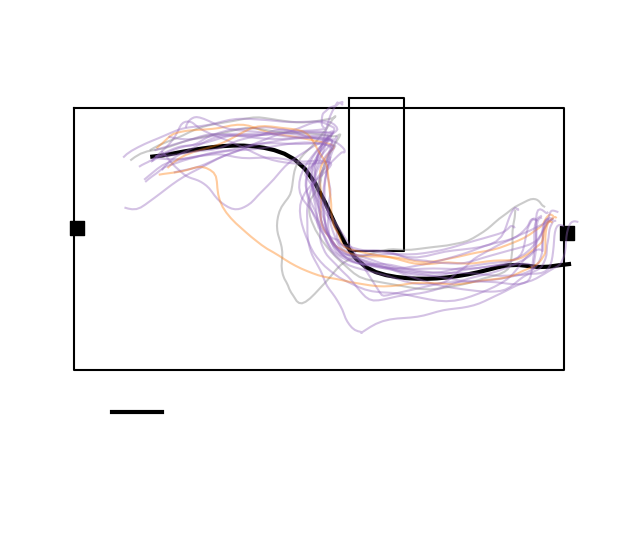

In [192]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oadark') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
ax.plot(light_nose_x, smooth(light_nose_y,1.5), linewidth=3, c = 'black')

light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
    # Determine color based on tortuosity value
    if 1 <= tortuosity < 1.33:
        color = 'tab:orange'
    elif 1.33 <= tortuosity < 1.66666667:
        color = 'tab:purple'
    elif 1.66666667 <= tortuosity:
        color = 'tab:grey'
 
    
    ax.plot(x, y, alpha=0.4, c=color)

ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\dark_tortuosity_trials.pdf",dpi = 300, transparent=True)


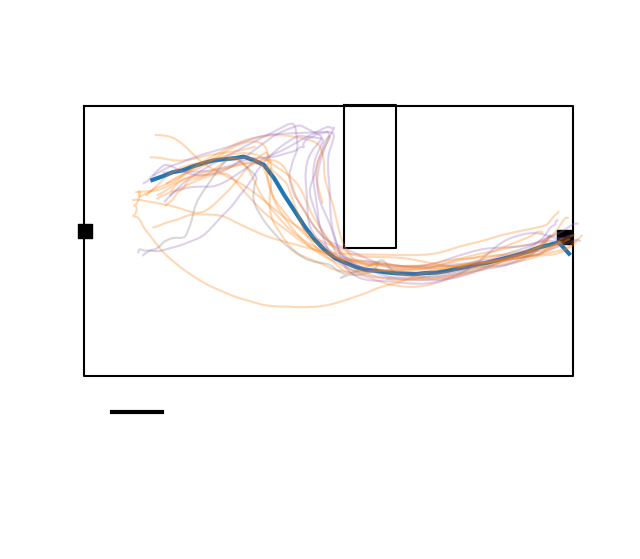

In [194]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
light = light_dark[(light_dark.obstacle_cluster == 1) & 
                   (light_dark.avg_lateral_error <= 0) & 
                   (light_dark.task == 'oa') & 
                   (light_dark.intial_distance >= 15) & 
                   (light_dark.obstacle_cross == True) & 
                   (light_dark.odd == 'left')]

ax.set_xticks([])
ax.set_yticks([])
plot_arena(light, ax)
ob_x, ob_y = plot_orginal_obstacle(light, ax, 5)

light_nose_y, light_nose_x = get_median_trajectory(light, x_key='ts_nose_x_cm', y_key='ts_nose_y_cm', turn_direction_key='odd')
ax.plot(light_nose_x, light_nose_y, linewidth=3)

light_sample_towards = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
light_sample_towards = light_sample_towards.sample(20)

for ind, row in light_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    tortuosity = row.tortuosity
    
    # Determine color based on tortuosity value
    if 1 <= tortuosity < 1.33:
        color = 'tab:orange'
    elif 1.33 <= tortuosity < 1.66666667:
        color = 'tab:purple'
    elif 1.66666667 <= tortuosity:
        color = 'tab:grey'
 
    
    ax.plot(x, y, alpha=0.3, c=color)

ax.plot((10,15), (38,38), c='black', linewidth=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\light_tortuosity_trials.pdf",dpi = 300, transparent=True)

meta NOT subset; don't know how to subset; dropped


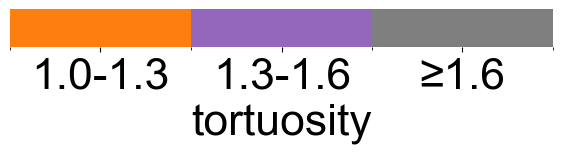

In [193]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib as mpl

# Define the colormap and boundaries
cmap = ListedColormap(['tab:orange', 'tab:purple', 'tab:grey'])
bounds = [1.0, 1.33, 1.66666667, 2.0]  # Boundaries for color transitions
norm = BoundaryNorm(bounds, cmap.N)

# Create a separate figure (wide and short for horizontal colorbar)
fig, ax = plt.subplots(figsize=(7, 1))  # Width x Height (adjust as needed)
fig.subplots_adjust(bottom=0.5)  # Make room for the colorbar

# Add the colorbar (horizontal orientation)
cbar = plt.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation='horizontal',  # Horizontal instead of vertical
    label='tortuosity',
    ticks=[1.165, 1.5, 1.83333],  # Midpoints of each range
)

# Customize labels (now on x-axis)
cbar.ax.set_xticklabels(['1.0-1.3', '1.3-1.6', '≥1.6'])  

# Remove unnecessary spines
ax.spines[:].set_visible(False)

plt.tight_layout()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\final_figure\tortuosity_colorbar.pdf",dpi = 300, transparent=True)
plt.show()


task
oa        3.349174
oadark    3.049722
Name: time, dtype: float64

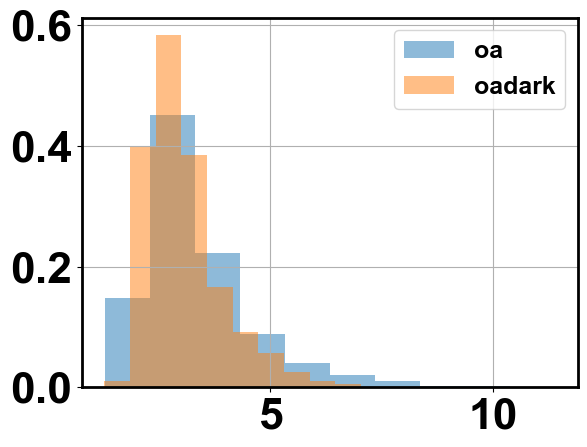

In [168]:
data = pd.concat([light_dark])
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 

data.groupby('task').time.hist(density = 'true',legend=True,alpha = .5)
data.groupby('task').time.mean()

task
oa        32.256189
oadark    32.258871
Name: avg_ts_speed, dtype: float64

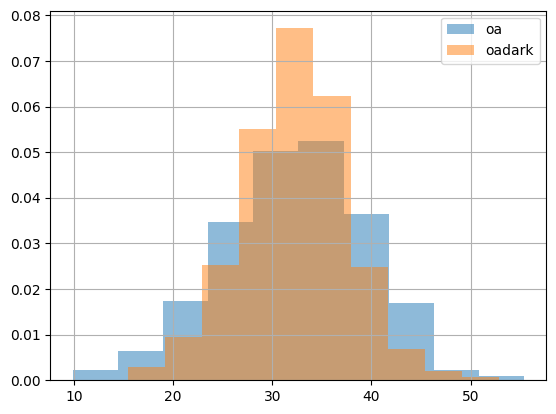

In [20]:
data = pd.concat([light_dark])
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0]
data = data[data.dist<=50] 


data.groupby('task').avg_ts_speed.hist(density = 'true',legend=True,alpha = .5)
data.groupby('task').avg_ts_speed.mean()

task
oa        1.295041
oadark    1.414150
Name: tortuosity, dtype: float64

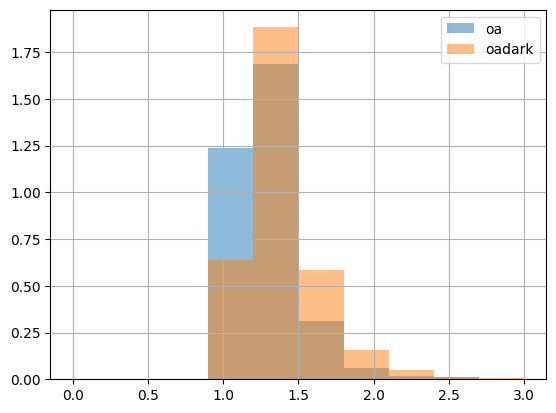

In [49]:
data = pd.concat([light_dark])
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

data.groupby('task').tortuosity.hist(range = (0,3),density = 'true',legend=True,alpha = .5)
data.groupby('task').tortuosity.mean()

task
oa        68.297794
oadark    74.081296
Name: ts_total_distance, dtype: float64

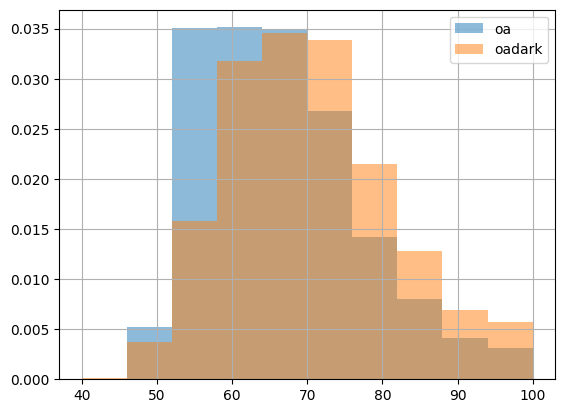

In [ ]:
data = pd.concat([light_dark])
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

data.groupby('task').ts_total_distance.hist(range = (40,100),density = 'true',legend=True,alpha = .5)
data.groupby('task').ts_total_distance.mean()

(array([163534., 144335., 169568., 193719., 161488.,  91332.,  21799.,
          2151.,    567.,    472.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

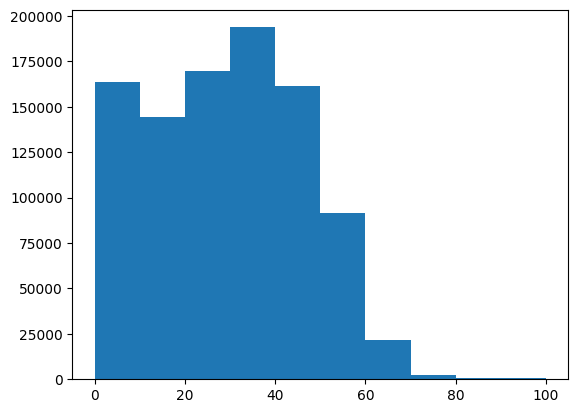

In [29]:
plt.hist(flatten_list_of_arrays(light_dark[light_dark.task=='oa'].ts_speed.to_list()),range = (0,100))

(array([1.13612948e-02, 1.39658067e-02, 2.11220247e-02, 2.67920496e-02,
        1.93230665e-02, 6.13198430e-03, 9.48997570e-04, 1.54465688e-04,
        1.12295117e-04, 8.80150920e-05]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

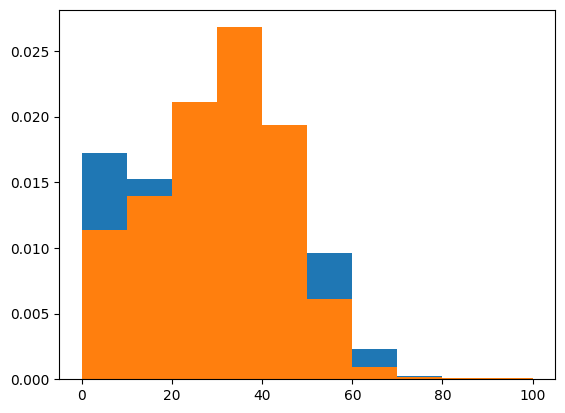

In [27]:
plt.hist(flatten_list_of_arrays(light_dark[light_dark.task=='oa'].ts_speed.to_list()),range = (0,100),density=True)
plt.hist(flatten_list_of_arrays(light_dark[light_dark.task=='oadark'].ts_speed.to_list()),range = (0,100),density=True)

In [7]:
dark.date_index.unique()

array([0., 1., 2., 3., 4., 5.])

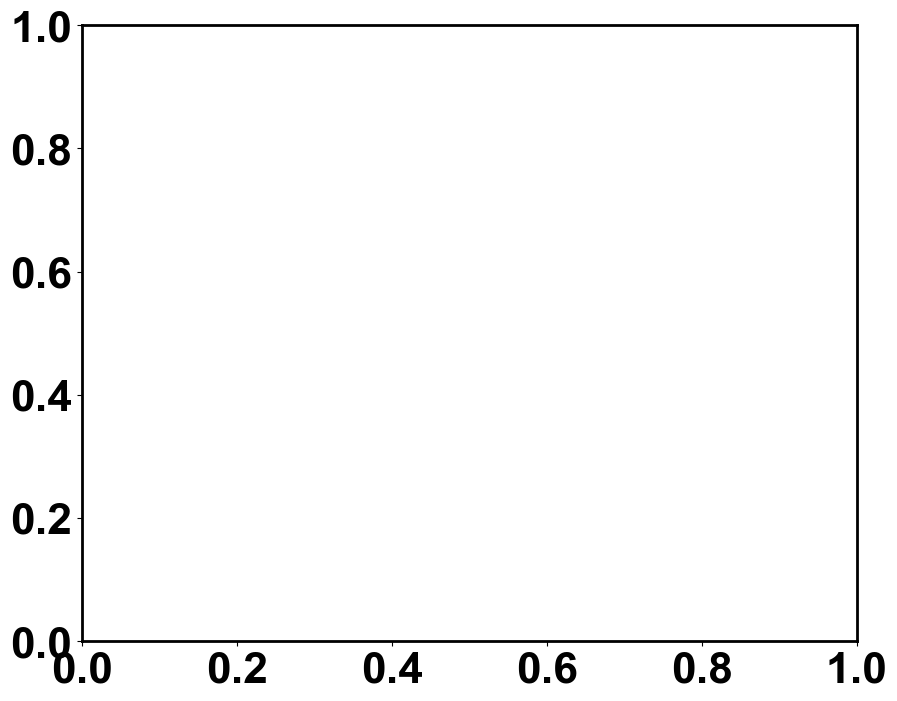

In [5]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=15]
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance<=15] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']

dark = data[data.task == 'oadark']


task
oa        65.768466
oadark    70.609572
Name: ts_total_distance, dtype: float64

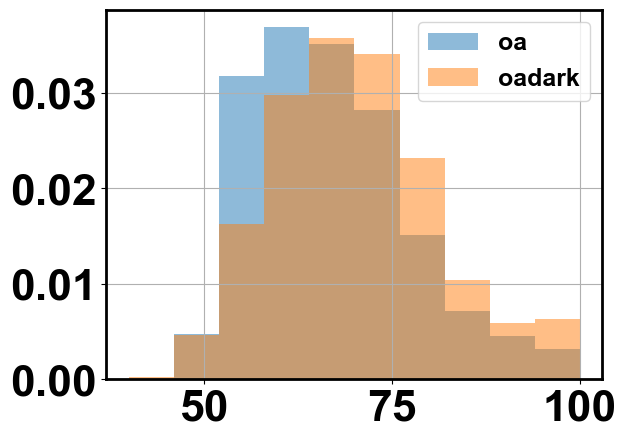

In [11]:
data = pd.concat([light_dark])
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

data.groupby('task').ts_total_distance.hist(range = (40,100),density = 'true',legend=True,alpha = .5)
data.groupby('task').ts_total_distance.median()

Animal medians in paired format:
task            oa     oadark
animal                       
G8CK1LN  66.851639  60.410410
G8CK1LT  65.082787  61.873999
G8CK1RT  65.956626  60.327438
G8CK1TT  62.169114  63.997970
G8CKLN   59.352114  63.933821
G8CKLT   61.383286  65.228200
G8CKRN   61.538225  66.845552
G8CKRT   60.496739  66.168292
G8CKTT   58.493105  65.257360

Number of animals with both conditions: 9

Paired Wilcoxon test results:
Task 1: oa, Task 2: oadark
Wilcoxon statistic: 16.0000
P-value: 0.4961
Significant at p < 0.05: False


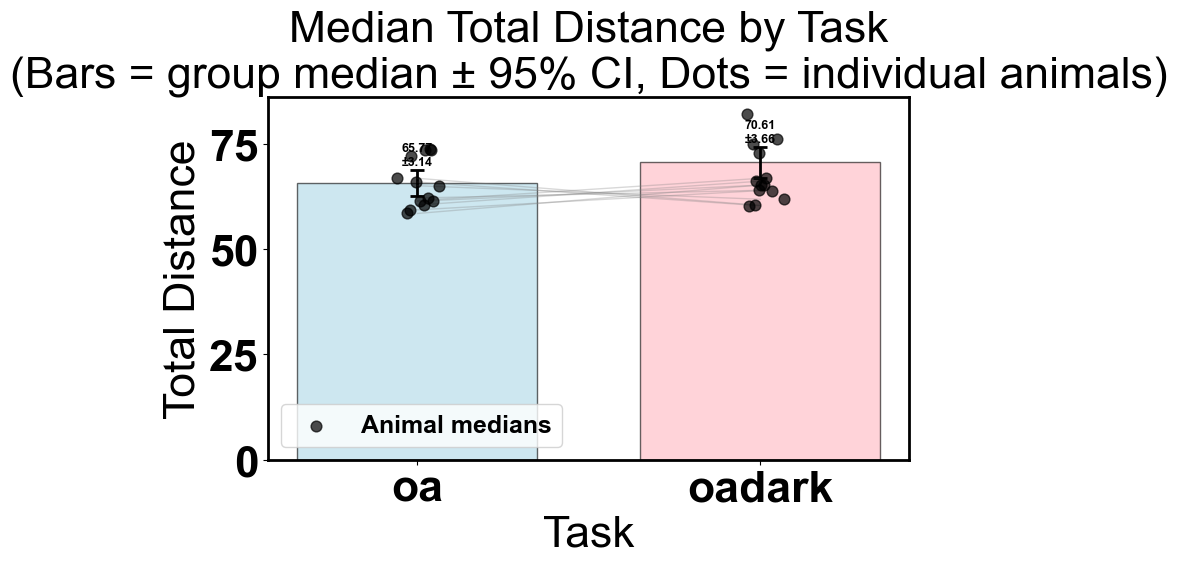


SEM by task (based on animal medians):
task
oa        1.604505
oadark    1.868014
Name: ts_total_distance, dtype: float64

95% CI ranges:
oa: ±3.14
oadark: ±3.66


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon

data = pd.concat([light_dark])
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

# Calculate group medians and animal medians
group_medians = data.groupby('task').ts_total_distance.median()
animal_medians = data.groupby(['task', 'animal']).ts_total_distance.median().reset_index()

# Calculate SEM using animal medians
sem_by_task = animal_medians.groupby('task')['ts_total_distance'].sem()

# Prepare data for paired test - pivot to get paired format
animal_paired = animal_medians.pivot(index='animal', columns='task', values='ts_total_distance').dropna()

print("Animal medians in paired format:")
print(animal_paired)
print(f"\nNumber of animals with both conditions: {len(animal_paired)}")

# Perform paired non-parametric test (Wilcoxon signed-rank test)
if len(animal_paired) > 1:
    # Get the two task columns
    task_columns = animal_paired.columns.tolist()
    task1, task2 = task_columns[0], task_columns[1]
    
    # Perform Wilcoxon test
    stat, p_value = wilcoxon(animal_paired[task1], animal_paired[task2])
    
    print(f"\nPaired Wilcoxon test results:")
    print(f"Task 1: {task1}, Task 2: {task2}")
    print(f"Wilcoxon statistic: {stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Significant at p < 0.05: {p_value < 0.05}")
else:
    print("\nNot enough paired data to perform Wilcoxon test")

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars with error bars
x_pos = np.arange(len(group_medians))
bars = ax.bar(x_pos, group_medians.values, alpha=0.6, 
              color=['lightblue', 'lightpink'], edgecolor='black', width=0.7,
              yerr=sem_by_task.values * 1.96,  # 95% CI (1.96 * SEM)
              capsize=5, error_kw={'elinewidth': 2, 'markeredgewidth': 2})

# Plot individual animal medians with lines connecting paired points
if len(animal_paired) > 0:
    # Create a mapping from task names to x-positions
    task_to_x = {task: i for i, task in enumerate(group_medians.index)}
    
    # Plot connecting lines for paired data
    for animal in animal_paired.index:
        x_coords = []
        y_coords = []
        for task in group_medians.index:
            if task in animal_paired.columns and not pd.isna(animal_paired.loc[animal, task]):
                x_coords.append(task_to_x[task])
                y_coords.append(animal_paired.loc[animal, task])
        
        if len(x_coords) == 2:  # Only plot if both conditions exist
            ax.plot(x_coords, y_coords, 'gray', alpha=0.3, linewidth=1)
    
    # Plot individual points
    for i, task in enumerate(group_medians.index):
        task_data = animal_medians[animal_medians['task'] == task]
        x_jittered = i + np.random.normal(0, 0.03, size=len(task_data))
        ax.scatter(x_jittered, task_data['ts_total_distance'], 
                  color='black', alpha=0.7, s=60, zorder=10, 
                  label='Animal medians' if i == 0 else "")

# Customize plot
ax.set_ylabel('Total Distance')
ax.set_xlabel('Task')
ax.set_xticks(x_pos)
ax.set_xticklabels(group_medians.index)

# Add value labels on bars
for i, (bar, sem) in enumerate(zip(bars, sem_by_task)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + sem * 1.96 + 0.5, 
            f'{height:.2f}\n±{sem * 1.96:.2f}', 
            ha='center', va='bottom', fontsize=9)

# Add significance annotation if test was performed
if len(animal_paired) > 1 and p_value < 0.05:
    y_max = max(group_medians.values + sem_by_task.values * 1.96) + 2
    ax.plot([0, 0, 1, 1], [y_max-1, y_max, y_max, y_max-1], 'k-', lw=1.5)
    ax.text(0.5, y_max + 0.5, '*' if p_value < 0.05 else f'p={p_value:.3f}', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Median Total Distance by Task\n(Bars = group median ± 95% CI, Dots = individual animals)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nSEM by task (based on animal medians):")
print(sem_by_task)
print(f"\n95% CI ranges:")
for task in sem_by_task.index:
    print(f"{task}: ±{sem_by_task[task] * 1.96:.2f}")

In [21]:
light_dist

array([ 84.84533356,  86.67741146, 107.44295016, ...,  71.28633339,
        52.56583952,  57.55913648])

In [22]:
light_cdf

array([4.51875282e-04, 9.03750565e-04, 1.35562585e-03, ...,
       9.99096249e-01, 9.99548125e-01, 1.00000000e+00])

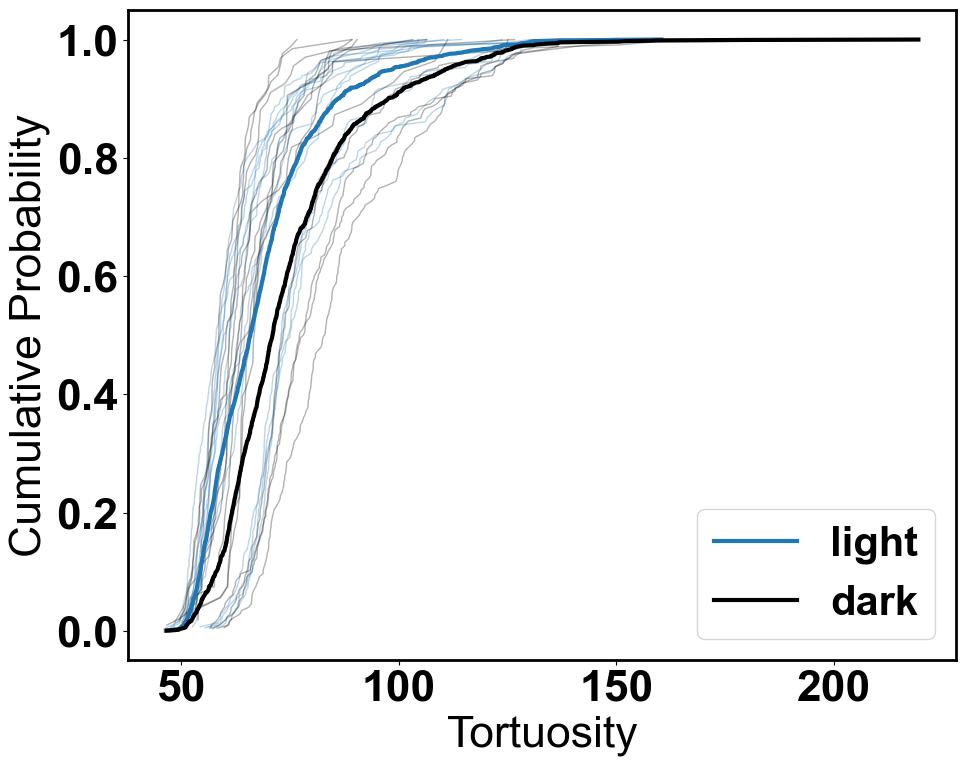

In [23]:
xnew = np.linspace(40, 100, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=15]
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance<=15] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']

light_dist = (light.ts_total_distance.to_numpy())
light_dist = light_dist[np.where((light_dist>=40))]

# Create CDF for light condition
light_sorted = np.sort(light_dist)
light_cdf = np.arange(1, len(light_sorted) + 1) / len(light_sorted)

# Process individual animals for light condition
light_cdf_individual = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.ts_total_distance.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=40))]
    
    if len(ani_light_dists) > 0:
        ani_sorted = np.sort(ani_light_dists)
        ani_cdf = np.arange(1, len(ani_sorted) + 1) / len(ani_sorted)
        light_cdf_individual.append((ani_sorted, ani_cdf))
        light_mean.append(np.nanmean(ani_light_dists))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.ts_total_distance.to_numpy())
dark_dist = dark_dist[np.where((dark_dist>=40))]

# Create CDF for dark condition
dark_sorted = np.sort(dark_dist)
dark_cdf = np.arange(1, len(dark_sorted) + 1) / len(dark_sorted)

# Process individual animals for dark condition
dark_cdf_individual = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.ts_total_distance.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=40))]
    
    if len(ani_dark_dists) > 0:
        ani_sorted = np.sort(ani_dark_dists)
        ani_cdf = np.arange(1, len(ani_sorted) + 1) / len(ani_sorted)
        dark_cdf_individual.append((ani_sorted, ani_cdf))
        dark_mean.append(np.nanmean(ani_dark_dists))

# Plot individual animal CDFs first (so they're behind the mean lines)
for x_vals, y_vals in light_cdf_individual:
    ax.plot(x_vals, y_vals, color='tab:blue', alpha=0.3, linewidth=1)

for x_vals, y_vals in dark_cdf_individual:
    ax.plot(x_vals, y_vals, color='black', alpha=0.3, linewidth=1)

# Plot mean CDF lines
ax.plot(light_sorted, light_cdf, color='tab:blue', linewidth=3, label='light')
ax.plot(dark_sorted, dark_cdf, color='black', linewidth=3, label='dark')

# Formatting
#ax.set_xlim(1, 2)
#ax.set_ylim(0, 1)
#ax.set_xticks([1, 1.5, 2])
#ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel('Cumulative Probability', fontweight='normal')
ax.set_xlabel('Tortuosity', fontweight='normal')

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='tab:blue', linewidth=3, label='light'),
    Line2D([0], [0], color='black', linewidth=3, label='dark')
]

ax.legend(handles=legend_handles, loc='lower right', fontsize=30, framealpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
xnew = np.linspace(1, 2, 10)
data = pd.concat([light_dark])

#data = data[data.intial_distance>=15]
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance<=15] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']

light_dist = (light.tortuosity.to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

# Create CDF for light condition
light_sorted = np.sort(light_dist)
light_cdf = np.arange(1, len(light_sorted) + 1) / len(light_sorted)

# Process individual animals for light condition
light_cdf_individual = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    if len(ani_light_dists) > 0:
        ani_sorted = np.sort(ani_light_dists)
        ani_cdf = np.arange(1, len(ani_sorted) + 1) / len(ani_sorted)
        light_cdf_individual.append((ani_sorted, ani_cdf))
        light_mean.append(np.nanmean(ani_light_dists))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.tortuosity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

# Create CDF for dark condition
dark_sorted = np.sort(dark_dist)
dark_cdf = np.arange(1, len(dark_sorted) + 1) / len(dark_sorted)

# Process individual animals for dark condition
dark_cdf_individual = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    if len(ani_dark_dists) > 0:
        ani_sorted = np.sort(ani_dark_dists)
        ani_cdf = np.arange(1, len(ani_sorted) + 1) / len(ani_sorted)
        dark_cdf_individual.append((ani_sorted, ani_cdf))
        dark_mean.append(np.nanmean(ani_dark_dists))

# Plot individual animal CDFs first (so they're behind the mean lines)
for x_vals, y_vals in light_cdf_individual:
    ax.plot(x_vals, y_vals, color='tab:blue', alpha=0.3, linewidth=1)

for x_vals, y_vals in dark_cdf_individual:
    ax.plot(x_vals, y_vals, color='black', alpha=0.3, linewidth=1)

# Plot mean CDF lines
ax.plot(light_sorted, light_cdf, color='tab:blue', linewidth=3, label='light')
ax.plot(dark_sorted, dark_cdf, color='black', linewidth=3, label='dark')

# Formatting
ax.set_xlim(1, 2)
ax.set_ylim(0, 1)
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel('Cumulative Probability', fontweight='normal')
ax.set_xlabel('Tortuosity', fontweight='normal')

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='tab:blue', linewidth=3, label='light'),
    Line2D([0], [0], color='black', linewidth=3, label='dark')
]

ax.legend(handles=legend_handles, loc='lower right', fontsize=30, framealpha=0.8)

plt.tight_layout()
plt.show()